# General Constrained Sampling

Michael Fatemi, 3/9/2026

This notebook includes several small-scale tests regarding the ability to sample from constrained distributions. We assess the coverage of the constrained distribution, and the affect of the annealing duration on this coverage. The general principle is that one can treat constraint satisfaction problems as attempting to perform Langevin dynamics sampling over a uniform distribution on a feasible set.

## Definition

Let's say we're trying to optimize over values in $\R^n$. Then the most general formulation of a constrained optimization problem is:
\begin{align*}
\min\ & f(x) \\
\text{subject to}\ & g_i(x) = 0 \\
& h_j(x) \leq 0
\end{align*}
Where $g_i: \R^n \to \R$ are functions having a feasible region denoted by $\mathcal{C}_i := g_i^{-1}(0)$, and $h_j: \R^n \to \R$ are functions having a feasible region denoted by $\mathcal{C}_j := h_i^{-1}((-\infty, 0])$. For simplicity, we will denote all feasible regions by $\mathcal{C}_i$, where the value of $i$ determines whether the feasible region corresponds to an equality or an inequality constraint. Therefore, if a value $x \in \R^n$ satisfies $x \in \mathcal{C}_i$, then $x$ satisfies constraint $i$. The overall feasible region for the problem is the feasible region for which all constraints are satisfied: $\mathcal{C} := \bigcap_i \mathcal{C}_i$. This is because $x \in \mathcal{C} \iff x \in \mathcal{C}_i \, \forall \, i$, representing the satisfaction of all constraints.

## Examples

- For a linear equality constraint $Ax = 0$, where $x \in V$ (a vector space) and $A \in V^*$ (the dual space), the feasible region is $\mathcal{C} \sube V$ a hyperplane.
- For a discrete constraint, i.e. $x \in \{0, 1, 2\}$, the feasible region is $\mathcal{C} = \{0, 1, 2\}$.
- For the inequality constraint $x \leq 0$ (for $x \in \R$), the feasible region is $\mathcal{C} = (-\infty, 0]$.
- For the inequality constraint $x + y \leq 0$ (for $x, y \in \R$), the feasible region is $\mathcal{C} = \{(x, y) \in \R^2 : x \leq -y \}$.
- For an "and" constraint on $x, y \in \{0, 1\}$, $x = 1, y = 1$, the feasible region is $\mathcal{C} = \{(1, 1)\}$.
- For an "or" constraint on $x, y \in \{0, 1\}$, $x = 1$ or $y = 1$, the feasible region is $\mathcal{C} = \{(0, 1), (1, 0), (1, 1)\}$.

## Convolved Distributions

Now, let's say we want to sample from a feasible region. To do this, we can consider annealed Langevin dynamics sampling. We must first define a distribution over the feasible region. For now, consider a bounded feasible region with nonzero measure. That is, $\mathcal{C} \sube B_r(0)$ for some $r \in \R$ finite, with $m(\mathcal{C}) > 0$ (where $m$ is the Lebesgue outer measure). Then we can define a probability space $(\Omega, \mathcal{F}, P)$, where $\Omega = \R^n$, $\mathcal{F} = \mathcal{B}$ (the Borel $\sigma$-algebra generated on $\R^n$), and $P(F) = \frac{m(F \cap \mathcal{C})}{m(\mathcal{C})}$. This is a uniform distribution over $\mathcal{C}$. Then let $P_\sigma$ be the same distribution, convolved with a normal distribution of variance $\sigma^2$, having probability density $p_\sigma$ given by:

$$
p_\sigma(x) = \int_{\R^n} \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) p(\tilde{x}) \, d\tilde{x}
$$

The "score" of this distribution is the gradient of log-probability:
\begin{align*}
\nabla*x \log p*\sigma(x)
&= \frac{\int*{\R^n} \nabla_x \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) p(\tilde{x}) \, d\tilde{x}}{\int*{\R^n} \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) p(\tilde{x}) \, d\tilde{x}} \\
&= \frac{\int*{\R^n} \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) \nabla_x \log \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) p(\tilde{x}) \, d\tilde{x}}{\int*{\R^n} \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) p(\tilde{x}) \, d\tilde{x}} \\
&= \frac{\int*{\R^n} \frac{\tilde{x} - x}{\sigma^2} \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) p(\tilde{x}) \, d\tilde{x}}{\int*{\R^n} \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) p(\tilde{x}) \, d\tilde{x}} \\
&=: \frac{N(x)}{D(x)}
\end{align*}
Where $N(x)$ refers to the "numerator" and $D(x)$ refers to the "denominator". This can then be used for sampling.

### Lower-Dimensional Convolved Distributions

The case above only applies for $m(\mathcal{C}) > 0$. However, for equality constraints, the feasible region is of lower dimension than the original space. To address this, we can let $g: \R^n \to \R$ represent the equality constraint $\mathcal{C} = g^{-1}(0)$. We may further require that the feasible region be a manifold; i.e., for the codimension $1$ case, $\nabla_x g(x) \neq 0$ for all $x \in \mathcal{C}$. Then we may define the feasible region $\mathcal{C}_{\epsilon} := g^{-1}(B_\epsilon(0))$. This has nonzero Lebesgue outer measure. Then we may take the limit of the full-dimensional case as $\epsilon \to 0$. For example, in the case of a plane, the score function will point normal to the plane. In the case of a feasible region defined by a set of points, the score function will be the same as that of a mixture of Gaussians with the mean of each Gaussian centered at each of the points.


## Example with Visualizations

Let's try sampling from the interval $[0, 1] \in \R$. We will try computing the score at a point $x \in \R$. Computing the score here can be done with the generalized Stokes theorem:
\begin{align*}
\nabla*x \log p*\sigma(x)
= \frac{\int*{\mathcal{C}} \nabla_x \mathcal{N}(\tilde{x} - x; 0, \sigma^2 I) \, d\tilde{x}}{\int*{\mathcal{C}} \mathcal{N}(\tilde{x} - x; 0, \sigma^2 I) \, d\tilde{x}}
= \frac{\int*{\delta \mathcal{C}} \mathcal{N}(\tilde{x} - x; 0, \sigma^2 I)}{\int*{\delta \mathcal{C}} \Phi(\frac{\tilde{x} - x}{\sigma})}
= \frac{\mathcal{N}(1 - x; 0, \sigma^2 I) - \mathcal{N}(-x; 0, \sigma^2 I)}{\Phi(\frac{1 - x}{\sigma}) - \Phi(\frac{-x}{\sigma})}
\end{align*}
Where $\Phi(x) = \int_{-\infty}^{x} \mathcal{N}(x; 0, I) \, dx$ is the Gaussian cumulative distribution function. We can visualize this at different noise levels $\sigma$. Note that the denominator, in this case, is $p_\sigma(x)$ itself.

<!-- We want:
$$
N(x) = \int_0^1 \frac{\tilde{x} - x}{\sigma^2} \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) \, d\tilde{x}
$$
If we change coordinates to $\epsilon = \frac{\tilde{x} - x}{\sigma}$, we have:
$$
N(x)
= \int_{\frac{x}{\sigma}}^{\frac{x - 1}{\sigma}} \epsilon \mathcal{N}(\epsilon; 0, I) \, d\epsilon
= \int_{\frac{x}{\sigma}}^{\frac{x - 1}{\sigma}} \frac{\epsilon}{\sqrt{2 \pi}} \exp\left(-\frac{\epsilon^2}{2}\right) \, d\epsilon
$$
Then note,
\begin{align*}
N(x)
&= \frac{1}{\sqrt{2 \pi}} \int_{\frac{x}{\sigma}}^{\frac{x - 1}{\sigma}} \frac{\partial}{\partial \epsilon} \exp\left(-\frac{\epsilon^2}{2}\right) \, d\epsilon \\
&= \left. \mathcal{N}(\epsilon; 0, I) \right|_{\epsilon = \frac{x - 1}{\sigma}}^{\frac{x}{\sigma}} \\
&= \mathcal{N}(x - 1; 0, \sigma^2 I) - \mathcal{N}(x; 0, \sigma^2 I)
\end{align*} -->


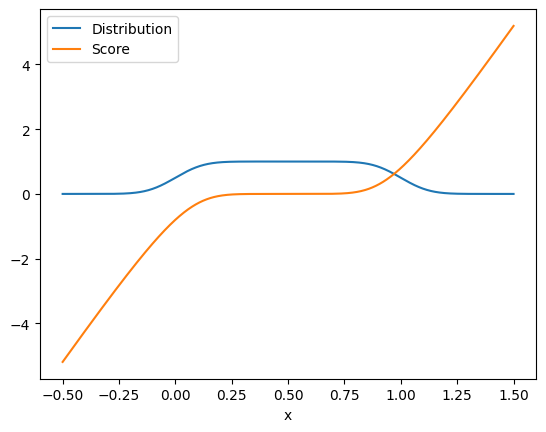

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

sigma = 0.1
x = np.linspace(-0.5, 1.5, 1000)

N = norm.pdf((1 - x) / sigma) - norm.pdf((-x / sigma))
D = norm.cdf((1 - x) / sigma) - norm.cdf((-x / sigma))

plt.plot(x, D, label="Distribution")
plt.plot(x, N / D, label="Score")
plt.xlabel("x")
plt.legend()
plt.show()


We see that the score gets increasingly powerful the further away one gets from the feasible region. However, I have purposefully truncated the bounds of the graph. Due to numerical precision errors, we start to get nonsense at far distances from the feasible region.


/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/2454122752.py:8: RuntimeWarning: divide by zero encountered in divide
  plt.plot(x, N / D, label='Score')


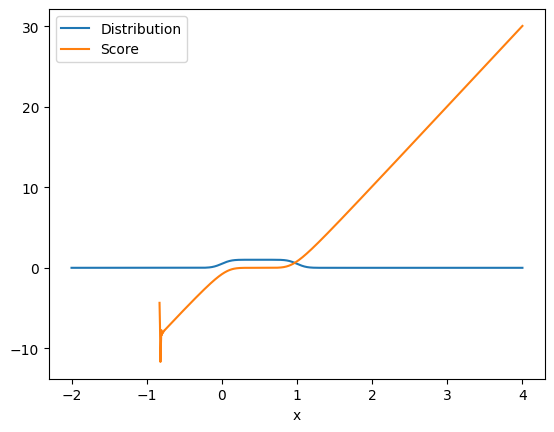

In [ ]:
sigma = 0.1
x = np.linspace(-2, 4, 1000)

N = norm.pdf((1 - x) / sigma) - norm.pdf((-x / sigma))
D = norm.cdf((1 - x) / sigma) - norm.cdf((-x / sigma))

plt.plot(x, D, label="Distribution")
plt.plot(x, N / D, label="Score")
plt.xlabel("x")
plt.legend()
plt.show()


To address this, we can note that Scipy provides a $\log \Phi$. Then we can cancel out any constant factors between the numerator and denominator, while preserving numerical stability. Sometimes the result for $\log \Phi$ is _extremely_ small, in which case we cannot even compute $\log D = \log(\exp(\log \Phi(\frac{1 - x}{\sigma})) - \exp(\log \Phi(\frac{-x}{\sigma})))$ numerically. In these cases, we can recognize that for very small $\log \Phi(\frac{1 - x}{\sigma})$, $\exp(\log \Phi(\frac{1 - x}{\sigma})) \approx 1 + \log \Phi(\frac{1 - x}{\sigma})$. The $1$ values will cancel out, leaving only the first-order terms remaining. Then $\log(\exp(\log \Phi(\frac{1 - x}{\sigma})) - \exp(\log \Phi(\frac{-x}{\sigma}))) \approx \log (\log \Phi(\frac{1 - x}{\sigma}) - \log \Phi (\frac{-x}{\sigma}))$. This value is stored in the `log_D_method_2` variable below. We see that more broadly, the score function pulls us to the feasible region strongly when we are outside of it. But, inside the feasible region, there is little "preference" as to where we are inside the feasible region, reflecting the fact that our original distribution was uniform over the feasible region.


/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/2159770297.py:10: RuntimeWarning: divide by zero encountered in log
  log_D_method_1 = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D


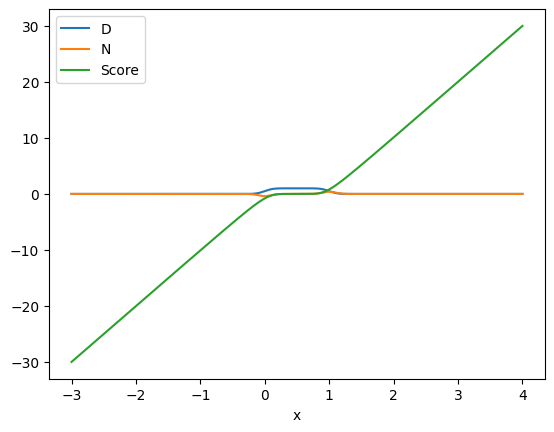

In [ ]:
from scipy.special import log_ndtr

sigma = 0.1
x = np.linspace(-3, 4, 1000)

log_D1 = log_ndtr((1 - x) / sigma)
log_D2 = log_ndtr(-x / sigma)

base_D = np.maximum(log_D1, log_D2)
log_D_method_1 = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D
log_D_method_2 = np.log(log_D1 - log_D2)
log_D = np.where(np.abs(base_D) > 1e-50, log_D_method_1, log_D_method_2)
D = np.exp(log_D)

log_N1 = -0.5 * (((1 - x) / sigma) ** 2) - 0.5 * np.log(2 * np.pi)
log_N2 = -0.5 * ((-x / sigma) ** 2) - 0.5 * np.log(2 * np.pi)
base_N = np.maximum(log_N1, log_N2)
log_N = np.log(np.abs(np.exp(log_N1 - base_N) - np.exp(log_N2 - base_N))) + base_N
N = np.exp(log_N) * np.sign(log_N1 - log_N2)


N_over_D = np.exp(log_N - log_D) * np.sign(log_N1 - log_N2)

plt.plot(x, D, label="D")
plt.plot(x, N, label="N")
plt.plot(x, N_over_D, label="Score")
plt.xlabel("x")
plt.legend()
plt.show()


But, it seems that for very small $\sigma$ values, this too fails.


/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/528109327.py:10: RuntimeWarning: divide by zero encountered in log
  log_D_method_1 = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D
/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/528109327.py:11: RuntimeWarning: divide by zero encountered in log
  log_D_method_2 = np.log(log_D1 - log_D2)


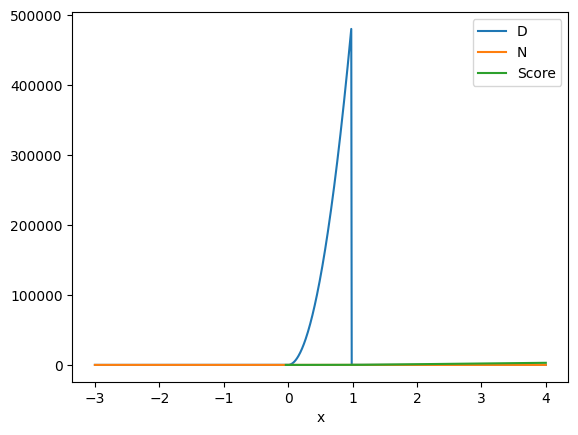

In [ ]:
from scipy.special import log_ndtr

sigma = 0.001
x = np.linspace(-3, 4, 1000)

log_D1 = log_ndtr((1 - x) / sigma)
log_D2 = log_ndtr(-x / sigma)

base_D = np.maximum(log_D1, log_D2)
log_D_method_1 = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D
log_D_method_2 = np.log(log_D1 - log_D2)
log_D = np.where(np.abs(base_D) > 1e-50, log_D_method_1, log_D_method_2)
D = np.exp(log_D)

log_N1 = -0.5 * (((1 - x) / sigma) ** 2) - 0.5 * np.log(2 * np.pi)
log_N2 = -0.5 * ((-x / sigma) ** 2) - 0.5 * np.log(2 * np.pi)
base_N = np.maximum(log_N1, log_N2)
log_N = np.log(np.abs(np.exp(log_N1 - base_N) - np.exp(log_N2 - base_N))) + base_N
N = np.exp(log_N) * np.sign(log_N1 - log_N2)


N_over_D = np.exp(log_N - log_D) * np.sign(log_N1 - log_N2)

plt.plot(x, D, label="D")
plt.plot(x, N, label="N")
plt.plot(x, N_over_D, label="Score")
plt.xlabel("x")
plt.legend()
plt.show()


A more robust to compute this is that for very large denominator inputs, we can negate the input to $\log \Phi$. This results in $\log 1 - \Phi$. Since $1 - \Phi$ will be close to zero, the $\log$ will have more meaning. In fact, one can numerically evaluate $\log 1 - \operatorname{erf}$ for very large $x$. Using this approach, we observe stability even for (very) small $\sigma$. In this limit, the score function points us directly to the feasible region. This resembles a _projection_. Furthermore, note that as $\sigma$ decreases, the _strength_ of the pull back to the feasible region gets significantly stronger.


/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/1097444700.py:9: RuntimeWarning: divide by zero encountered in log
  log_D = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D
/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/1097444700.py:15: RuntimeWarning: divide by zero encountered in log
  np.log(np.exp(log_D2_alt - base_D_alt) - np.exp(log_D1_alt - base_D_alt))


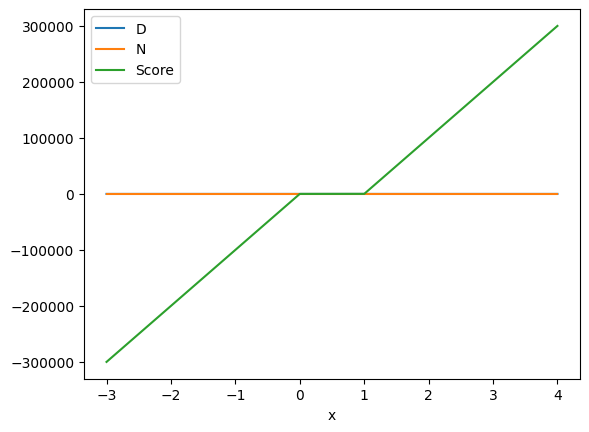

In [81]:
from scipy.special import log_ndtr

sigma = 0.00001
x = np.linspace(-3, 4, 1000)

log_D1 = log_ndtr((1 - x) / sigma)
log_D2 = log_ndtr(-x / sigma)
base_D = np.maximum(log_D1, log_D2)
log_D = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D

log_D1_alt = log_ndtr((x - 1) / sigma)
log_D2_alt = log_ndtr(x / sigma)
base_D_alt = np.maximum(log_D1_alt, log_D2_alt)
log_D_alt = (
    np.log(np.exp(log_D2_alt - base_D_alt) - np.exp(log_D1_alt - base_D_alt))
    + base_D_alt
)
log_D = np.where(x > 0, log_D, log_D_alt)
D = np.exp(log_D)

log_N1 = -0.5 * (((1 - x) / sigma) ** 2) - 0.5 * np.log(2 * np.pi)
log_N2 = -0.5 * ((-x / sigma) ** 2) - 0.5 * np.log(2 * np.pi)
base_N = np.maximum(log_N1, log_N2)
log_N = np.log(np.abs(np.exp(log_N1 - base_N) - np.exp(log_N2 - base_N))) + base_N
N = np.exp(log_N) * np.sign(log_N1 - log_N2)


N_over_D = np.exp(log_N - log_D) * np.sign(log_N1 - log_N2)

plt.plot(x, D, label="D")
plt.plot(x, N, label="N")
plt.plot(x, N_over_D, label="Score")
plt.xlabel("x")
plt.legend()
plt.show()


We can now visualize what happens if we anneal $\log \sigma$ linearly.


In [317]:
from scipy.special import log_ndtr
from io import BytesIO
import PIL.Image
import av
from IPython.display import Video

nframes = 30
images = []
bytes_io = BytesIO()
for log_sigma in np.linspace(np.log(10), np.log(0.00001), nframes):
    sigma = np.exp(log_sigma)
    x = np.linspace(0 - 10 * sigma - 0.1, 1 + 10 * sigma + 0.1, 1000)

    log_D1 = log_ndtr((1 - x) / sigma)
    log_D2 = log_ndtr(-x / sigma)
    base_D = np.maximum(log_D1, log_D2)
    log_D = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D

    log_D1_alt = log_ndtr((x - 1) / sigma)
    log_D2_alt = log_ndtr(x / sigma)
    base_D_alt = np.maximum(log_D1_alt, log_D2_alt)
    log_D_alt = (
        np.log(np.exp(log_D2_alt - base_D_alt) - np.exp(log_D1_alt - base_D_alt))
        + base_D_alt
    )
    log_D = np.where(x > 0, log_D, log_D_alt)
    D = np.exp(log_D)

    log_N1 = -0.5 * (((1 - x) / sigma) ** 2) - 0.5 * np.log(2 * np.pi)
    log_N2 = -0.5 * ((-x / sigma) ** 2) - 0.5 * np.log(2 * np.pi)
    base_N = np.maximum(log_N1, log_N2)
    log_N = np.log(np.abs(np.exp(log_N1 - base_N) - np.exp(log_N2 - base_N))) + base_N
    N = np.exp(log_N) * np.sign(log_N1 - log_N2)

    N_over_D = np.exp(log_N - log_D) * np.sign(log_N2 - log_N1)

    plt.plot(x, D, label="D")
    plt.plot(x, N, label="N")
    plt.plot(x, N_over_D, label="Score")
    plt.xlabel("x")
    plt.legend()
    plt.savefig(bytes_io, format="png")
    plt.clf()
    img = PIL.Image.open(bytes_io).convert("RGB")
    images.append(img)

    bytes_io.truncate(0)
    bytes_io.seek(0)

with av.open("animation.mp4", mode="w") as container:
    stream = container.add_stream("h264", rate=10)
    stream.width = images[0].width
    stream.height = images[0].height
    stream.pix_fmt = "yuv420p"

    for img in images:
        packet = stream.encode(av.VideoFrame.from_image(img))
        container.mux(packet)

    # Flush the encoder
    for packet in stream.encode(None):
        container.mux(packet)

Video("animation.mp4")


/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/241665875.py:17: RuntimeWarning: divide by zero encountered in log
  log_D = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D
/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/241665875.py:23: RuntimeWarning: divide by zero encountered in log
  np.log(np.exp(log_D2_alt - base_D_alt) - np.exp(log_D1_alt - base_D_alt))


<Figure size 640x480 with 0 Axes>

Now, let's say we want to intersect two constraints. What does the resulting landscape look like? For now, let's consider a $[0, 2]$ constraint and a $[1, 3]$ constraint. We'll find that the final constraint satisfies both intervals.


In [ ]:
def compute_log_D_1D_interval(x, x0, x1, sigma):
    log_D1 = log_ndtr((x1 - x) / sigma)
    log_D2 = log_ndtr((x0 - x) / sigma)
    base_D = np.maximum(log_D1, log_D2)
    log_D = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D

    log_D1_alt = log_ndtr((x - x1) / sigma)
    log_D2_alt = log_ndtr((x - x0) / sigma)
    base_D_alt = np.maximum(log_D1_alt, log_D2_alt)
    log_D_alt = (
        np.log(np.exp(log_D2_alt - base_D_alt) - np.exp(log_D1_alt - base_D_alt))
        + base_D_alt
    )
    log_D = np.where(x > (x0 + x1) / 2, log_D, log_D_alt)

    return log_D


def compute_log_N_and_sign_interval(x, x0, x1, sigma):
    log_N_upper = -0.5 * (((x1 - x) / sigma) ** 2) - 0.5 * np.log(2 * np.pi)
    log_N_lower = -0.5 * (((x0 - x) / sigma) ** 2) - 0.5 * np.log(2 * np.pi)
    base_N = np.maximum(log_N_upper, log_N_lower)
    log_N = (
        np.log(np.abs(np.exp(log_N_upper - base_N) - np.exp(log_N_lower - base_N)))
        + base_N
    )
    sign = -np.sign(log_N_upper - log_N_lower)

    return log_N, sign

In [319]:
from scipy.special import log_ndtr
from io import BytesIO
import PIL.Image
import av
from IPython.display import Video

plt.figure(figsize=(12, 5))

nframes = 30
images = []
bytes_io = BytesIO()
for log_sigma in np.linspace(np.log(10), np.log(0.00001), nframes):
    sigma = np.exp(log_sigma)
    r = max(0.001, min(10 * sigma, 1))
    x = np.linspace(0 - r, 3 + r, 1000)

    log_D_dist1 = compute_log_D_1D_interval(x, 0, 2, sigma)
    log_D_dist2 = compute_log_D_1D_interval(x, 1, 3, sigma)
    log_N_dist1_x, sign_dist1_x = compute_log_N_and_sign_interval(x, 0, 2, sigma)
    log_N_dist2, sign_dist2 = compute_log_N_and_sign_interval(x, 1, 3, sigma)

    D = np.exp(log_D_dist1 + log_D_dist2)

    score_dist1 = np.exp(log_N_dist1_x - log_D_dist1) * sign_dist1_x
    score_dist2 = np.exp(log_N_dist2 - log_D_dist2) * sign_dist2
    score = score_dist1 + score_dist2

    plt.subplot(1, 2, 1)
    plt.plot(x, D, label="Distribution")
    plt.plot(x, score, label="Score")
    plt.xlabel("x")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(x, D, label="Distribution")
    plt.xlabel("x")
    plt.legend()

    plt.tight_layout()

    plt.savefig(bytes_io, format="png")
    plt.clf()
    img = PIL.Image.open(bytes_io).convert("RGB")
    images.append(img)

    bytes_io.truncate(0)
    bytes_io.seek(0)

plt.close()

with av.open("animation.mp4", mode="w") as container:
    stream = container.add_stream("h264", rate=10)
    stream.width = images[0].width
    stream.height = images[0].height
    stream.pix_fmt = "yuv420p"

    for img in images:
        packet = stream.encode(av.VideoFrame.from_image(img))
        container.mux(packet)

    # Flush the encoder
    for packet in stream.encode(None):
        container.mux(packet)

Video("animation.mp4")


/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/3487296226.py:11: RuntimeWarning: divide by zero encountered in log
  np.log(np.exp(log_D2_alt - base_D_alt) - np.exp(log_D1_alt - base_D_alt))
/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/3487296226.py:5: RuntimeWarning: divide by zero encountered in log
  log_D = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D


What if we have really _wide_ constraints? Plotting the individual distributions independently, we can visualize what happens:


In [320]:
from scipy.special import log_ndtr
from io import BytesIO
import PIL.Image
import av
from IPython.display import Video

plt.figure(figsize=(12, 5))

interval1 = (0, 10)
interval2 = (3, 13)

nframes = 30
images = []
bytes_io = BytesIO()
for log_sigma in np.linspace(np.log(10), np.log(0.00001), nframes):
    sigma = np.exp(log_sigma)
    r = max(0.001, min(10 * sigma, 1))
    x = np.linspace(interval1[0] - r, interval2[1] + r, 1000)

    log_D_dist1 = compute_log_D_1D_interval(x, interval1[0], interval1[1], sigma)
    log_D_dist2 = compute_log_D_1D_interval(x, interval2[0], interval2[1], sigma)
    log_N_dist1_x, sign_dist1_x = compute_log_N_and_sign_interval(
        x, interval1[0], interval1[1], sigma
    )
    log_N_dist2, sign_dist2 = compute_log_N_and_sign_interval(
        x, interval2[0], interval2[1], sigma
    )

    D = np.exp(log_D_dist1 + log_D_dist2)

    score_dist1 = np.exp(log_N_dist1_x - log_D_dist1) * sign_dist1_x
    score_dist2 = np.exp(log_N_dist2 - log_D_dist2) * sign_dist2
    score = score_dist1 + score_dist2

    plt.subplot(1, 2, 1)
    plt.plot(x, np.exp(log_D_dist1), label="Distribution 1")
    plt.plot(x, np.exp(log_D_dist2), label="Distribution 2")
    plt.plot(x, D, label="Distribution")
    plt.plot(x, score, label="Score")
    plt.xlabel("x")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(x, np.exp(log_D_dist1), label="Distribution 1")
    plt.plot(x, np.exp(log_D_dist2), label="Distribution 2")
    plt.plot(x, D, label="Distribution")
    plt.xlabel("x")
    plt.legend()

    plt.tight_layout()

    plt.savefig(bytes_io, format="png")
    plt.clf()
    img = PIL.Image.open(bytes_io).convert("RGB")
    images.append(img)

    bytes_io.truncate(0)
    bytes_io.seek(0)

plt.close()

with av.open("animation.mp4", mode="w") as container:
    stream = container.add_stream("h264", rate=10)
    stream.width = images[0].width
    stream.height = images[0].height
    stream.pix_fmt = "yuv420p"

    for img in images:
        packet = stream.encode(av.VideoFrame.from_image(img))
        container.mux(packet)

    # Flush the encoder
    for packet in stream.encode(None):
        container.mux(packet)

Video("animation.mp4")


/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/3487296226.py:11: RuntimeWarning: divide by zero encountered in log
  np.log(np.exp(log_D2_alt - base_D_alt) - np.exp(log_D1_alt - base_D_alt))
/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/3487296226.py:5: RuntimeWarning: divide by zero encountered in log
  log_D = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D


## Box Constraints

What if we want to constrain values to lie within the _box_ $\mathcal{C} := [a_1, b_1] \times \ldots \times [a_n, b_n] \sube \R^n$? This can be done analytically. Appealing again to the divergence theorem, we have:
\begin{align*}
\nabla*x \log p*\sigma(x)
&= \frac{\int*{\mathcal{C}} \nabla_x \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) \, d\tilde{x}}{\int*{\mathcal{C}} \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) \, d\tilde{x}} \\
&= \frac{\int*{\delta \mathcal{C}} \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) \, d\vec{a}}{\prod_i (\Phi(b_i) - \Phi(a_i))} \\
&= \frac{\sum_i \vec{e}\_i (\mathcal{N}(b_i; 0, \sigma^2) - \mathcal{N}(a_i; 0, \sigma^2 I)) \prod*{j \neq i} (\Phi(b_j/\sigma) - \Phi(a_j/\sigma))}{\prod_i (\Phi(b_i/\sigma) - \Phi(a_i/\sigma))}
\end{align*}
The numerator makes use of the fact that we have one "surface" for each dimension $i$. For each of these surfaces, $\mathcal{N}(x - \tilde{x}; 0, \sigma^2 I)$ is constant for dimensions $j \neq i$. Integrating over the $j \neq i$ dimensions gives us the product term of individual CDFs (which can be thought of as integrating over each of the $j \neq i$ dimensions individually). Then there is a factor of $\vec{e}_i \mathcal{N}(b_i; 0, \sigma^2)$ for the surface $\{x \in \mathcal{C} : x_i = b_i\}$ and a factor of $-\vec{e}_i \mathcal{N}(a_i; 0, \sigma^2)$ for the surface $\{x \in \mathcal{C} : x_i = a_i\}$. This computation is $O(d)$. In fact, the denominator may be "cancelled into" the numerator:
\begin{align*}
\nabla*x \log p*\sigma(x)
&= \sum_i \vec{e}\_i \frac{\mathcal{N}(b_i; 0, \sigma^2) - \mathcal{N}(a_i; 0, \sigma^2 I)}{\Phi(b_i/\sigma) - \Phi(a_i/\sigma)}
\end{align*}
Conveniently, these "box constraint" scores are precisely the sum of the scores for the individual intervals! We can visualize them in a 2D heatmap.


In [321]:
from io import BytesIO
import PIL.Image
import av
from IPython.display import Video


plt.figure(figsize=(12, 5))

box1 = ((0, 10), (0, 10))
box2 = ((3, 13), (5, 8))

nframes = 30
images = []
bytes_io = BytesIO()
for log_sigma in np.linspace(np.log(10), np.log(0.00001), nframes):
    sigma = np.exp(log_sigma)
    r = max(2, min(10 * sigma, 1))

    x, y = np.meshgrid(
        np.linspace(box1[0][0] - r, box2[0][1] + r, 100),
        np.linspace(box1[1][0] - r, box2[1][1] + r, 100),
    )

    log_D_dist1_x = compute_log_D_1D_interval(x, box1[0][0], box1[0][1], sigma)
    log_D_dist1_y = compute_log_D_1D_interval(y, box1[1][0], box1[1][1], sigma)
    log_N_dist1_x, sign_dist1_x = compute_log_N_and_sign_interval(
        x, box1[0][0], box1[0][1], sigma
    )
    log_N_dist1_y, sign_dist1_y = compute_log_N_and_sign_interval(
        y, box1[1][0], box1[1][1], sigma
    )

    log_D_dist2_x = compute_log_D_1D_interval(x, box2[0][0], box2[0][1], sigma)
    log_D_dist2_y = compute_log_D_1D_interval(y, box2[1][0], box2[1][1], sigma)
    log_N_dist2_x, sign_dist2_x = compute_log_N_and_sign_interval(
        x, box2[0][0], box2[0][1], sigma
    )
    log_N_dist2_y, sign_dist2_y = compute_log_N_and_sign_interval(
        y, box2[1][0], box2[1][1], sigma
    )

    D = np.exp(log_D_dist1_x + log_D_dist1_y + log_D_dist2_x + log_D_dist2_y)

    score_dist1_x = np.exp(log_N_dist1_x - log_D_dist1_x) * sign_dist1_x
    score_dist1_y = np.exp(log_N_dist1_y - log_D_dist1_y) * sign_dist1_y
    score_dist2_x = np.exp(log_N_dist2_x - log_D_dist2_x) * sign_dist2_x
    score_dist2_y = np.exp(log_N_dist2_y - log_D_dist2_y) * sign_dist2_y
    score_x = score_dist1_x + score_dist2_x
    score_y = score_dist1_y + score_dist2_y

    plt.subplot(1, 2, 1)
    plt.title("Distribution")
    plt.imshow(
        D, extent=(x.min(), x.max(), y.min(), y.max()), origin="lower", alpha=0.5
    )
    plt.subplot(1, 2, 2)
    plt.title("Score Vector Field")
    score_norm = np.sqrt(score_x**2 + score_y**2) + 1e-8
    score_x_normalized = score_x / score_norm
    score_y_normalized = score_y / score_norm
    plt.imshow(
        D, extent=(x.min(), x.max(), y.min(), y.max()), origin="lower", alpha=0.5
    )
    dx = x[0, 1] - x[0, 0]
    dy = y[1, 0] - y[0, 0]
    plt.quiver(
        x,
        y,
        score_x_normalized,
        score_y_normalized,
        color="red",
        angles="xy",
        scale_units="xy",
        scale=1.0 / (dx**2 + dy**2) ** 0.5,
    )
    plt.xlim(x.min(), x.max())
    plt.ylim(y.min(), y.max())
    plt.tight_layout()

    plt.savefig(bytes_io, format="png")
    plt.clf()
    img = PIL.Image.open(bytes_io).convert("RGB")
    images.append(img)

    bytes_io.truncate(0)
    bytes_io.seek(0)

plt.close()

with av.open("animation.mp4", mode="w") as container:
    stream = container.add_stream("h264", rate=10)
    stream.width = images[0].width
    stream.height = images[0].height
    stream.pix_fmt = "yuv420p"

    for img in images:
        packet = stream.encode(av.VideoFrame.from_image(img))
        container.mux(packet)

    # Flush the encoder
    for packet in stream.encode(None):
        container.mux(packet)


/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/3487296226.py:11: RuntimeWarning: divide by zero encountered in log
  np.log(np.exp(log_D2_alt - base_D_alt) - np.exp(log_D1_alt - base_D_alt))
/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/3487296226.py:5: RuntimeWarning: divide by zero encountered in log
  log_D = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D


In [327]:
Video("animation.mp4")

We observe that the score function points to the feasible region, hardening up for small $\sigma$ values.

Note that if we want to constrain to the _complement_ of a box, however, we will not be able to make this simple cancellation. Instead,
\begin{align*}
\nabla*x \log p*\sigma(x)
&= \frac{\int*{\mathcal{C}} \nabla_x \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) \, d\tilde{x}}{\int*{\mathcal{C}} \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) \, d\tilde{x}} \\
&= \frac{\int*{\delta \mathcal{C}} \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) d\vec{a}}{1 - \int*{\mathcal{C}} \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) \, d\tilde{x}} \\
&= \frac{\sum*i -\vec{e}\_i (\mathcal{N}(b_i; 0, \sigma^2) - \mathcal{N}(a_i; 0, \sigma^2)) \prod*{j \neq i} (\Phi(b_j/\sigma) - \Phi(a_j/\sigma))}{1 - \prod_i (\Phi(b_i/\sigma) - \Phi(a_i/\sigma))} \\
\end{align*}
While the numerator for the individual components is the same as the previous case (just negated), the denominator has changed. Therefore, we may _sum_ the log of the denominator across all cases, exponentiate it, and then subtract it from $1$. Note that this will often simply be $0$. Furthermore, we sum the log of the numerator with the sum of the log of the other denominators.


In [ ]:
from io import BytesIO
import PIL.Image
import av
from IPython.display import Video


plt.figure(figsize=(12, 5))

box1 = ((0, 10), (0, 10))

nframes = 30
images = []
bytes_io = BytesIO()
for log_sigma in np.linspace(np.log(10), np.log(0.00001), nframes):
    sigma = np.exp(log_sigma)
    r = max(2, min(10 * sigma, 1))

    x, y = np.meshgrid(
        np.linspace(box1[0][0] - r, box1[0][1] + r, 100),
        np.linspace(box1[1][0] - r, box1[1][1] + r, 100),
    )

    log_D_dist1_complement_x = compute_log_D_1D_interval(
        x, box1[0][0], box1[0][1], sigma
    )
    log_D_dist1_complement_y = compute_log_D_1D_interval(
        y, box1[1][0], box1[1][1], sigma
    )
    log_N_dist1_x, sign_dist1_x = compute_log_N_and_sign_interval(
        x, box1[0][0], box1[0][1], sigma
    )
    log_N_dist1_y, sign_dist1_y = compute_log_N_and_sign_interval(
        y, box1[1][0], box1[1][1], sigma
    )
    D = 1 - np.exp(log_D_dist1_complement_x + log_D_dist1_complement_y)
    log_D_method_1 = np.log(D)
    log_D_method_2 = -(log_D_dist1_complement_x + log_D_dist1_complement_y)
    log_D = np.where(D > 1e-20, log_D_method_1, log_D_method_2)

    score_dist1_x = (
        np.exp(log_N_dist1_x + log_D_dist1_complement_y - log_D) * -sign_dist1_x
    )
    score_dist1_y = (
        np.exp(log_N_dist1_y + log_D_dist1_complement_x - log_D) * -sign_dist1_y
    )
    score_x = score_dist1_x
    score_y = score_dist1_y

    plt.subplot(1, 2, 1)
    plt.title("Distribution")
    plt.imshow(
        D, extent=(x.min(), x.max(), y.min(), y.max()), origin="lower", alpha=0.5
    )
    plt.subplot(1, 2, 2)
    plt.title("Score Vector Field")
    score_norm = np.sqrt(score_x**2 + score_y**2) + 1e-8
    score_x_normalized = score_x / score_norm
    score_y_normalized = score_y / score_norm
    plt.imshow(
        D, extent=(x.min(), x.max(), y.min(), y.max()), origin="lower", alpha=0.5
    )
    dx = x[0, 1] - x[0, 0]
    dy = y[1, 0] - y[0, 0]
    plt.quiver(
        x,
        y,
        score_x_normalized,
        score_y_normalized,
        color="red",
        angles="xy",
        scale_units="xy",
        scale=1.0 / (dx**2 + dy**2) ** 0.5,
    )
    plt.xlim(x.min(), x.max())
    plt.ylim(y.min(), y.max())
    plt.tight_layout()

    plt.savefig(bytes_io, format="png")
    plt.clf()
    img = PIL.Image.open(bytes_io).convert("RGB")
    images.append(img)

    bytes_io.truncate(0)
    bytes_io.seek(0)

plt.close()

with av.open("animation.mp4", mode="w") as container:
    stream = container.add_stream("h264", rate=10)
    stream.width = images[0].width
    stream.height = images[0].height
    stream.pix_fmt = "yuv420p"

    for img in images:
        packet = stream.encode(av.VideoFrame.from_image(img))
        container.mux(packet)

    # Flush the encoder
    for packet in stream.encode(None):
        container.mux(packet)


/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/4268856924.py:36: RuntimeWarning: divide by zero encountered in log
  log_D_method_1 = np.log(D)
/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/2975279431.py:12: RuntimeWarning: divide by zero encountered in log
  log_D = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D
/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/2975279431.py:18: RuntimeWarning: divide by zero encountered in log
  np.log(np.exp(log_D2_alt - base_D_alt) - np.exp(log_D1_alt - base_D_alt))


In [177]:
Video("animation.mp4")

/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/2975279431.py:12: RuntimeWarning: divide by zero encountered in log
  log_D = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D
/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/2975279431.py:18: RuntimeWarning: divide by zero encountered in log
  np.log(np.exp(log_D2_alt - base_D_alt) - np.exp(log_D1_alt - base_D_alt))
/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/977853868.py:7: RuntimeWarning: divide by zero encountered in log
  log_D_method_1 = np.log(D)


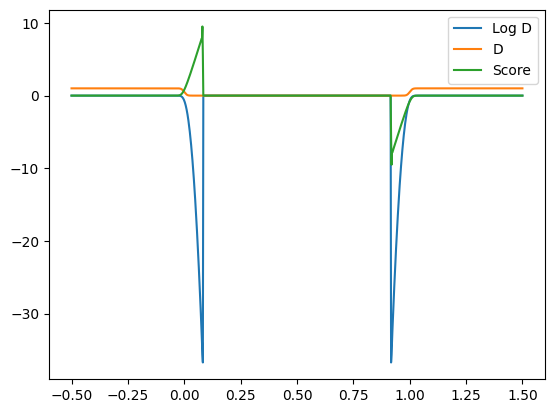

In [192]:
# Let me debug on a single variable interval first.

sigma = 0.01
x = np.linspace(-0.5, 1.5, 1000)
log_D = compute_log_D_1D_interval(x, 0, 1, sigma)
D = 1 - np.exp(log_D)
log_D_method_1 = np.log(D)
log_D_method_2 = -log_D
log_D = np.where(D > 0, log_D_method_1, log_D_method_2)
log_N, sign = compute_log_N_and_sign_interval(x, 0, 1, sigma)
plt.plot(x, log_D, label="Log D")
plt.plot(x, D, label="D")
plt.plot(x, np.exp(log_N - log_D) * sign, label="Score")
plt.legend()
plt.show()

Ah, I see what's going on. In the original case, $D \to 1$ inside the box. But now, $D \to 0$ inside the box, and if we compute $D$ via $1 - \exp(\log D')$ (where $D'$ is the $D$ value for the "include the box" constraint), $\log D' = 0$ in some cases. Therefore, we must be able to represent $D$ as a _log of a complement_ as well. To do this, we note $D$ becomes a _sum_ of two CDFs. Therefore we can do a log-sum-exp. Particularly, for the region $[a, b]$, if we want to compute:

$$
\log (1 - D) = \log\left(1 - \int_a^b \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) \, d\tilde{x}\right)
$$

We can do this via:
\begin{align*}
\log (1 - D)
&= \log\left(1 - \left(\int*{-\infty}^b \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) \, d\tilde{x} - \int*{-\infty}^a \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) \, d\tilde{x} \right)\right) \\
&= \log\left(1 - \left(\int*{-\infty}^b \mathcal{N}(\tilde{x} - x; 0, \sigma^2 I) \, d\tilde{x} - \int*{-\infty}^a \mathcal{N}(\tilde{x} - x; 0, \sigma^2 I) \, d\tilde{x} \right)\right) \\
&= \log\left(1 - \left(\int*{-\infty}^{b - x} \mathcal{N}(u; 0, \sigma^2 I) \, du - \int*{-\infty}^{a - x} \mathcal{N}(u; 0, \sigma^2 I) \, du \right)\right) \\
&= \log\left(\Phi\left(\frac{a - x}{\sigma}\right) + \Phi\left(\frac{x - b}{\sigma}\right) \right) \\
&= \log\left(\exp \log \Phi\left(\frac{a - x}{\sigma}\right) + \exp \log \Phi\left(\frac{x - b}{\sigma}\right) \right) \\
\end{align*}
Where $\log \Phi$ is a numerically stable function provided by scipy. Note that in this case, we don't need to have separate cases. For $x \gg a$, $\log \Phi((a - x)/\sigma) \ll 0$ and $\log \Phi((x - b)/\sigma)$ will dominate (while still being on the "small" side). If $x \ll a$, then $\log \Phi((a - x)/\sigma) \to 0$, dominating $\log \Phi((x - b)/\sigma) \to -\infty$ (and vice versa on the other side).


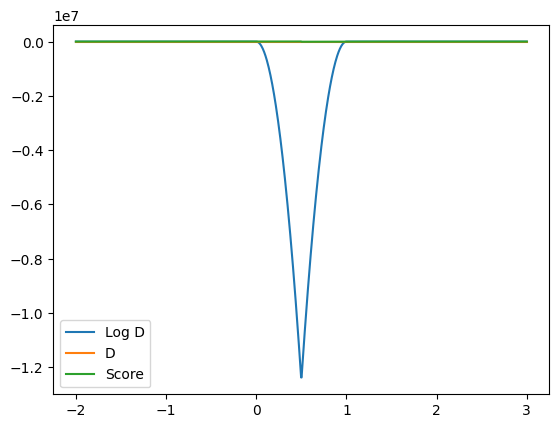

In [211]:
def compute_log_D_1D_complement_interval(x, x0, x1, sigma):
    log_D1 = log_ndtr((x0 - x) / sigma)
    log_D2 = log_ndtr((x - x1) / sigma)
    base_D = np.maximum(log_D1, log_D2)
    log_D_complement = (
        np.log(np.exp(log_D1 - base_D) + np.exp(log_D2 - base_D)) + base_D
    )
    return log_D_complement


sigma = 0.0001
x = np.linspace(-2, 3, 1000)
log_D = compute_log_D_1D_complement_interval(x, 0, 1, sigma)
D = np.exp(log_D)
log_N, sign = compute_log_N_and_sign_interval(x, 0, 1, sigma)
plt.plot(x, log_D, label="Log D")
plt.plot(x, D, label="D")
plt.plot(x, np.exp(log_N - log_D) * sign, label="Score")
plt.legend()
plt.show()

Now, how can we use this to stably compute $\log D = \log (1 - \prod_i (\Phi(b_i / \sigma) - \Phi(a_i / \sigma)))$? Note that $\prod_i (\Phi(b_i/\sigma) - \Phi(a_i/\sigma)) = \exp \sum_i \log (\Phi(b_i/\sigma) - \Phi(a_i/\sigma))$. We only expect $D$ to matter when $\prod_i (\Phi(b_i / \sigma) - \Phi(a_i / \sigma))$ takes on relatively large values. This requires _none_ of $\Phi(b_i/\sigma) - \Phi(a_i/\sigma)$ to be small, since $\Phi(b_i/\sigma) - \Phi(a_i/\sigma) < 1$. Or, particularly, none of $1 - (\Phi(b_i/\sigma) - \Phi(a_i/\sigma))$ can be large. This can be determined by our $\log (1 - (\Phi(b_i/\sigma) - \Phi(a_i/\sigma)))$ function derived above, which stores useful information about variations _close to 1_ of $\Phi(b_i/\sigma) - \Phi(a_i/\sigma)$.

Another strategy could be inductive; i.e., we perform the computation dimension-by-dimension. First consider a scenario in which we have two dimensions. If we have a square in the middle, this divides space into 9 regions if the sides of the square are extended out to infinity. If we number them in the following way:

```
 1 | 2 | 3
---+---+---
 4 | 5 | 6
---+---+---
 7 | 8 | 9
```

Let's say the vertical lines have $x$ values $x_1$ and $x_2$, and the horizontal lines have $y$ values of $y_1$ and $y_2$. Our goal is to compute $D$ by summing the integrals for these individual cells, which we assume we can do in closed form as we did in the first "self-contained" box case. Then we can compute the contributions to the denominator for regions 1, 4, 7, 3, 6, and 9 through the 1D case in the $x$ dimension. But this leaves regions $2$ and $8$ to compute. To do this, we note that if we were to integrate $2$ and $8$ simultaneously, there would be an integral in $x$ and an integral in $y$. These integrals would factorize; i.e., there is a factor $\mathcal{N}(x; 0, \sigma^2)$ and a factor $\mathcal{N}(y; 0, \sigma^2)$. Therefore we can compute the $x$ integral via a CDF. Then the $y$ integral reduces to the 1-dimensional problem. Thus, this integral can be computed recursively through log-sum-exp.


In [ ]:
def box_complement_log_denominator(
    box: list[tuple[float, float]], x: np.ndarray, sigma: float
):
    log_d0 = compute_log_D_1D_complement_interval(
        x[..., 0], box[0][0], box[0][1], sigma
    )
    if len(box) > 1:
        log_d1 = box_complement_log_denominator(
            box[1:], x[..., 1:], sigma
        ) + compute_log_D_1D_interval(x[..., 0], box[0][0], box[0][1], sigma)
        base = np.maximum(log_d0, log_d1)
        return np.log(np.exp(log_d0 - base) + np.exp(log_d1 - base)) + base
    return log_d0


plt.figure(figsize=(12, 5))

box1 = [(0, 10), (0, 10)]

nframes = 30
images = []
bytes_io = BytesIO()
num = 50

for log_sigma in np.linspace(np.log(10), np.log(0.00001), nframes):
    # for log_sigma in [np.log(0.0001)]:
    sigma = np.exp(log_sigma)
    r = max(2, min(10 * sigma, 1))

    x, y = np.meshgrid(
        np.linspace(box1[0][0] - r, box1[0][1] + r, num),
        np.linspace(box1[1][0] - r, box1[1][1] + r, num),
    )

    log_D_dist1_complement_x = compute_log_D_1D_complement_interval(
        x, box1[0][0], box1[0][1], sigma
    )
    log_D_dist1_complement_y = compute_log_D_1D_complement_interval(
        y, box1[1][0], box1[1][1], sigma
    )
    log_D_dist1_including_box_x = compute_log_D_1D_interval(
        x, box1[0][0], box1[0][1], sigma
    )
    log_D_dist1_including_box_y = compute_log_D_1D_interval(
        y, box1[1][0], box1[1][1], sigma
    )
    log_N_dist1_x, sign_dist1_x = compute_log_N_and_sign_interval(
        x, box1[0][0], box1[0][1], sigma
    )
    log_N_dist1_y, sign_dist1_y = compute_log_N_and_sign_interval(
        y, box1[1][0], box1[1][1], sigma
    )
    log_D = box_complement_log_denominator(box1, np.stack([x, y], axis=-1), sigma)
    log_D_for_including_box = log_D_dist1_including_box_x + log_D_dist1_including_box_y

    D = np.exp(log_D)
    score_dist1_x = (
        np.exp(
            log_N_dist1_x
            - log_D
            + log_D_for_including_box
            - log_D_dist1_including_box_x
        )
        * -sign_dist1_x
    )
    score_dist1_y = (
        np.exp(
            log_N_dist1_y
            - log_D
            + log_D_for_including_box
            - log_D_dist1_including_box_y
        )
        * -sign_dist1_y
    )
    score_x = score_dist1_x
    score_y = score_dist1_y

    plt.subplot(1, 2, 1)
    plt.title("Distribution")
    plt.imshow(
        D, extent=(x.min(), x.max(), y.min(), y.max()), origin="lower", alpha=0.5
    )
    plt.subplot(1, 2, 2)
    plt.title("Score Vector Field")
    score_norm = np.sqrt(score_x**2 + score_y**2)
    score_x_normalized = score_x / (score_norm + 1e-40)
    score_y_normalized = score_y / (score_norm + 1e-40)
    plt.imshow(
        D, extent=(x.min(), x.max(), y.min(), y.max()), origin="lower", alpha=0.5
    )
    dx = x[0, 1] - x[0, 0]
    dy = y[1, 0] - y[0, 0]
    plt.quiver(
        x,
        y,
        score_x_normalized,
        score_y_normalized,
        color="red",
        angles="xy",
        scale_units="xy",
        scale=1.0 / (dx**2 + dy**2) ** 0.5,
    )
    plt.xlim(x.min(), x.max())
    plt.ylim(y.min(), y.max())
    plt.colorbar()
    plt.tight_layout()
    # plt.show()

    plt.savefig(bytes_io, format="png")
    plt.clf()
    img = PIL.Image.open(bytes_io).convert("RGB")
    images.append(img)

    bytes_io.truncate(0)
    bytes_io.seek(0)

plt.close()

with av.open("animation.mp4", mode="w") as container:
    stream = container.add_stream("h264", rate=10)
    stream.width = images[0].width
    stream.height = images[0].height
    stream.pix_fmt = "yuv420p"

    for img in images:
        packet = stream.encode(av.VideoFrame.from_image(img))
        container.mux(packet)

    # Flush the encoder
    for packet in stream.encode(None):
        container.mux(packet)


/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/2975279431.py:12: RuntimeWarning: divide by zero encountered in log
  log_D = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D
/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/2975279431.py:18: RuntimeWarning: divide by zero encountered in log
  np.log(np.exp(log_D2_alt - base_D_alt) - np.exp(log_D1_alt - base_D_alt))


In [282]:
Video("animation.mp4")

We see now that the score function pulls us _out_ of the infeasible box and into the feasible region. Once the feasible region is reached, the score function ceases to apply. The score function arrows disappear when they have magnitude $0$. Now, let's package this up into a nice couple of modular functions.


In [347]:
def box_complement_log_denominator(
    box: list[tuple[float, float]], x: np.ndarray, sigma: float
):
    log_d0 = compute_log_D_1D_complement_interval(
        x[..., 0], box[0][0], box[0][1], sigma
    )
    if len(box) > 1:
        log_d1 = box_complement_log_denominator(
            box[1:], x[..., 1:], sigma
        ) + compute_log_D_1D_interval(x[..., 0], box[0][0], box[0][1], sigma)
        base = np.maximum(log_d0, log_d1)
        return np.log(np.exp(log_d0 - base) + np.exp(log_d1 - base)) + base
    return log_d0


def box_inclusion_score_and_likelihood(x, box, sigma):
    arrays = []
    log_D_per_dim = np.array(
        [
            compute_log_D_1D_interval(x[..., i], box[i][0], box[i][1], sigma)
            for i in range(x.shape[-1])
        ]
    )
    for i in range(x.shape[-1]):
        log_N, sign = compute_log_N_and_sign_interval(
            x[..., i], box[i][0], box[i][1], sigma
        )
        arrays.append(np.exp(log_N - log_D_per_dim[i]) * sign)
    return np.stack(arrays, axis=-1), log_D_per_dim.sum(axis=0)


def box_exclusion_score_and_likelihood(x, box, sigma):
    log_D = box_complement_log_denominator(box, x, sigma)
    log_D_per_dim_for_inclusion = np.array(
        [
            compute_log_D_1D_interval(x[..., i], box[i][0], box[i][1], sigma)
            for i in range(x.shape[-1])
        ]
    )
    log_D_including_box = log_D_per_dim_for_inclusion.sum(axis=0)
    arrays = []
    for i in range(x.shape[-1]):
        # this is signed for the 'inclusion' case. negate sign for exclusion.
        log_N, sign = compute_log_N_and_sign_interval(
            x[..., i], box[i][0], box[i][1], sigma
        )
        arrays.append(
            np.exp(
                log_N - log_D + (log_D_including_box - log_D_per_dim_for_inclusion[i])
            )
            * -sign
        )
    return np.stack(arrays, axis=-1), log_D


/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/1830745625.py:5: RuntimeWarning: divide by zero encountered in log
  log_D = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D
/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/1830745625.py:11: RuntimeWarning: divide by zero encountered in log
  np.log(np.exp(log_D2_alt - base_D_alt) - np.exp(log_D1_alt - base_D_alt))


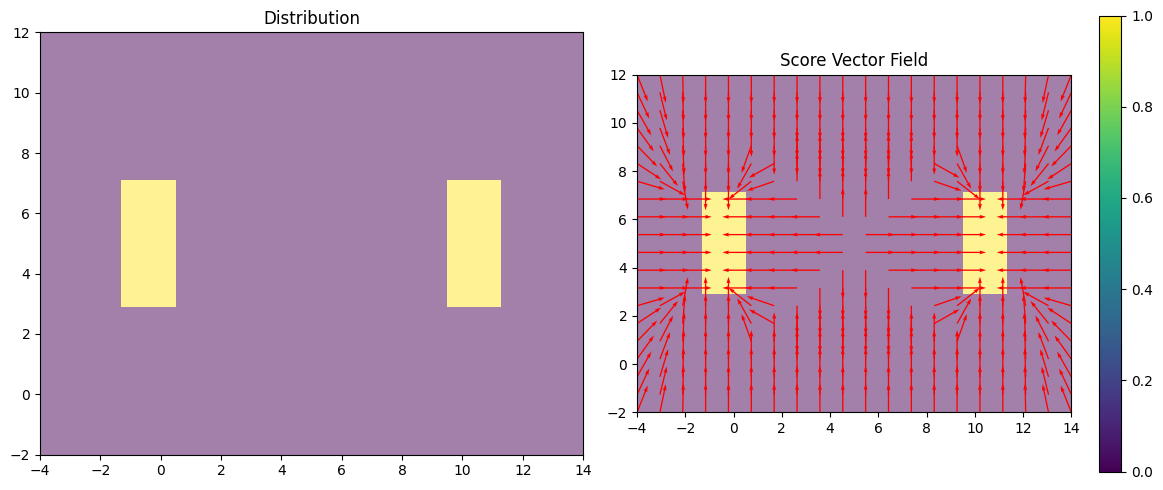

In [440]:
plt.figure(figsize=(12, 5))

box1 = [(0, 10), (0, 10)]
box2 = [(-2, 12), (3, 7)]

nframes = 30
images = []
bytes_io = BytesIO()
num = 20

# for log_sigma in np.linspace(np.log(10), np.log(0.00001), nframes):
for log_sigma in [np.log(0.001)]:
    sigma = np.exp(log_sigma)
    r = max(2, min(10 * sigma, 1))

    xx, yy = np.meshgrid(
        np.linspace(-2 - r, 12 + r, num),
        np.linspace(0 - r, 10 + r, num),
    )
    x = np.stack([xx, yy], axis=-1)

    box1_exclusion_score, box1_exclusion_likelihood = (
        box_exclusion_score_and_likelihood(x, box1, sigma)
    )
    box2_inclusion_score, box2_inclusion_likelihood = (
        box_inclusion_score_and_likelihood(x, box2, sigma)
    )
    score_x = box1_exclusion_score[..., 0] + box2_inclusion_score[..., 0]
    score_y = box1_exclusion_score[..., 1] + box2_inclusion_score[..., 1]
    # score_x = box2_inclusion_score[..., 0]
    # score_y = box2_inclusion_score[..., 1]

    D = np.exp(box1_exclusion_likelihood + box2_inclusion_likelihood)
    # D = np.exp(box2_inclusion_likelihood)

    plt.subplot(1, 2, 1)
    plt.title("Distribution")
    plt.imshow(
        D, extent=(xx.min(), xx.max(), yy.min(), yy.max()), origin="lower", alpha=0.5
    )
    plt.subplot(1, 2, 2)
    plt.title("Score Vector Field")
    score_norm = np.sqrt(score_x**2 + score_y**2)
    score_x_normalized = score_x / (score_norm + 1e-40)
    score_y_normalized = score_y / (score_norm + 1e-40)
    plt.imshow(
        D, extent=(xx.min(), xx.max(), yy.min(), yy.max()), origin="lower", alpha=0.5
    )
    dx = xx[0, 1] - xx[0, 0]
    dy = yy[1, 0] - yy[0, 0]
    plt.quiver(
        xx,
        yy,
        score_x_normalized,
        score_y_normalized,
        color="red",
        angles="xy",
        scale_units="xy",
        scale=1.0 / ((dx**2 + dy**2) ** 0.5),
    )
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    # plt.savefig(bytes_io, format="png")
    # plt.clf()
    # img = PIL.Image.open(bytes_io).convert("RGB")
    # images.append(img)

    # bytes_io.truncate(0)
    # bytes_io.seek(0)

plt.close()

# with av.open("animation.mp4", mode="w") as container:
#     stream = container.add_stream("h264", rate=10)
#     stream.width = images[0].width
#     stream.height = images[0].height
#     stream.pix_fmt = "yuv420p"

#     for img in images:
#         packet = stream.encode(av.VideoFrame.from_image(img))
#         container.mux(packet)

#     # Flush the encoder
#     for packet in stream.encode(None):
#         container.mux(packet)


It is true that there are local minima in the resulting energy landscape; however, they should not be entered with high probability. Let us implement a Langevin dynamics sampler, with a very small step size, so that we can observe the evolution of the distribution over time. It will take in a score function parametrizable by $\sigma$: $\nabla_{x} p_\sigma(x) = s(x, \sigma)$, $s: \R^n \times [0, \infty) \to \R^n$.


In [810]:
box1 = [(0, 10), (0, 10)]
box2 = [(-2, 12), (3, 7)]


def two_boxes_score(x, sigma):
    box1_exclusion_score, box1_exclusion_likelihood = (
        box_exclusion_score_and_likelihood(x, box1, sigma)
    )
    box2_inclusion_score, box2_inclusion_likelihood = (
        box_inclusion_score_and_likelihood(x, box2, sigma)
    )
    return box1_exclusion_score + box2_inclusion_score


def langevin_step(score_fn, x, sigma, step_size):
    score = score_fn(x, sigma)
    if isinstance(score, tuple):
        score = score[0]
    score_norm = np.sqrt(np.sum(score**2, axis=-1, keepdims=True)) + 1e-40
    score_scaling_factor = np.minimum(100 / score_norm, 1.0)
    return x + (
        step_size * score_scaling_factor * score
        + np.sqrt(2 * step_size) * np.random.randn(*x.shape)
    )


def langevin_simulation(score_fn, x, sigma_values, step_size=None):
    x_hist = [x]
    for sigma in sigma_values:
        x = langevin_step(score_fn, x, sigma, step_size=step_size or sigma * 0.1)
        x_hist.append(x)
    return x_hist


def save_video(images: list[PIL.Image.Image], filename: str, rate=10):
    with av.open(filename, mode="w") as container:
        stream = container.add_stream("h264", rate=rate)
        stream.width = images[0].width
        stream.height = images[0].height
        stream.pix_fmt = "yuv420p"

        for img in images:
            packet = stream.encode(av.VideoFrame.from_image(img))
            container.mux(packet)

        for packet in stream.encode(None):
            container.mux(packet)


In [ ]:
n_particles = 100
n_steps = 10000
sigma_values = np.exp(np.linspace(np.log(10), np.log(0.1), n_steps))
# sigma_values = np.ones(n_steps)
initial_x = np.random.randn(n_particles, 2) * 2 + np.array([5, 5])
x_hist = langevin_simulation(
    two_boxes_score,
    initial_x,
    sigma_values,
    step_size=0.1,
)

num = 100
xx, yy = np.meshgrid(
    np.linspace(-2 - r, 12 + r, num),
    np.linspace(0 - r, 10 + r, num),
)
x = np.stack([xx, yy], axis=-1)

imgs = []

bytes_io = BytesIO()
for i in range(1, len(x_hist), n_steps // 100):
    display_sigma = sigma_values[i - 1]
    box1_exclusion_likelihood = box_complement_log_denominator(box1, x, display_sigma)
    box2_inclusion_likelihood = np.array(
        [
            compute_log_D_1D_interval(x[..., i], box2[i][0], box2[i][1], display_sigma)
            for i in range(x.shape[-1])
        ]
    ).sum(axis=0)
    D = np.exp(box1_exclusion_likelihood + box2_inclusion_likelihood)

    plt.imshow(D, extent=(xx.min(), xx.max(), yy.min(), yy.max()), origin="lower")
    plt.scatter(x_hist[i][:, 0], x_hist[i][:, 1], alpha=0.5)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.savefig(bytes_io, format="png")
    plt.clf()

    img = PIL.Image.open(bytes_io, formats=["png"]).convert("RGB")
    imgs.append(img)
    bytes_io.seek(0)
    bytes_io.truncate(0)

save_video(imgs, "langevin_simulation.mp4", rate=10)


/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/1830745625.py:11: RuntimeWarning: divide by zero encountered in log
  np.log(np.exp(log_D2_alt - base_D_alt) - np.exp(log_D1_alt - base_D_alt))
/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/1830745625.py:5: RuntimeWarning: divide by zero encountered in log
  log_D = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D


<Figure size 640x480 with 0 Axes>

In [705]:
Video("langevin_simulation.mp4")

Here we see a nice simulation of annealed Langevin! Interestingly, if we perform the annealing correctly, no samples get caught in the local minimum. Let's compare what happens if we start from the wrong stationary distribution at a low noise level.


In [ ]:
n_particles = 100
n_steps = 100
sigma_values = np.ones(n_steps) * 0.0001
initial_x = np.random.randn(n_particles, 2) * 8 + np.array([5, 5])
x_hist = langevin_simulation(
    two_boxes_score,
    initial_x,
    sigma_values,
    step_size=0.0001,
)

num = 100
xx, yy = np.meshgrid(
    np.linspace(-2 - r, 12 + r, num),
    np.linspace(0 - r, 10 + r, num),
)
x = np.stack([xx, yy], axis=-1)

imgs = []

bytes_io = BytesIO()
for i in range(1, len(x_hist), n_steps // 100):
    display_sigma = sigma_values[i - 1]
    box1_exclusion_likelihood = box_complement_log_denominator(box1, x, display_sigma)
    box2_inclusion_likelihood = np.array(
        [
            compute_log_D_1D_interval(x[..., i], box2[i][0], box2[i][1], display_sigma)
            for i in range(x.shape[-1])
        ]
    ).sum(axis=0)
    D = np.exp(box1_exclusion_likelihood + box2_inclusion_likelihood)

    plt.imshow(D, extent=(xx.min(), xx.max(), yy.min(), yy.max()), origin="lower")
    plt.scatter(x_hist[i][:, 0], x_hist[i][:, 1], alpha=0.5)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.savefig(bytes_io, format="png")
    plt.clf()

    img = PIL.Image.open(bytes_io, formats=["png"]).convert("RGB")
    imgs.append(img)
    bytes_io.seek(0)
    bytes_io.truncate(0)

save_video(imgs, "langevin_simulation.mp4", rate=10)


/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/1830745625.py:5: RuntimeWarning: divide by zero encountered in log
  log_D = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D
/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/1830745625.py:11: RuntimeWarning: divide by zero encountered in log
  np.log(np.exp(log_D2_alt - base_D_alt) - np.exp(log_D1_alt - base_D_alt))


<Figure size 640x480 with 0 Axes>

In [448]:
Video("langevin_simulation_localmins.mp4")

We find that some samples get stuck in the local minima because the initial distribution was not the _stationary distribution_ of a sufficiently close noise level. Now, what happens if we try to sample from something like $3 SAT$? The $3 SAT$ problem is an NP-complete problem (meaning any other NP-complete problem has a polynomial-time reduction to it). Given a collection of Boolean variables and _clauses_, which are three-variable disjunctions, $3 SAT$ asks whether there is an assignment of true or false to each of the variables that makes all of the clauses true. For example, "$x_1 \lor x_2 \lor \lnot x_3$" is a clause stating that $x_1$ is true, $x_2$ is true, or $x_3$ is false. Equivalently, this clause can be rewritten as $\lnot (\lnot x_1 \land \lnot x_2 \land x_3)$ using DeMorgan's low, which is just that the logical "not" distributes to conjunctions or disjunctions, by applying the not to each of the propositions internal to it and then flipping the conjunction to a disjunction or vice versa.

We have created enough machinery here to define an energy landscape for $3 SAT$. Any clause may be expressed as an exclusion constraint from the box created by conjuncting the negated constituents of the original clause. Furthermore, we may want to constrain the final variable values to a discrete set. To do this, we can do the following.

Let's say our feasible region $\mathcal{C}$ consists of a countable number of points $\{p_1, \ldots, p_n\}$. Then when we convolve it, we get a mixture of Gaussians:
\begin{align*}
p*\sigma(x) = \frac{1}{n} \sum*{i=1}^{n} \mathcal{N}(p_i - x; 0, \sigma^2 I)
\end{align*}
Then the score is:
\begin{align*}
\nabla*x \log p*\sigma(x) = \frac{\sum*{i=1}^{n} \frac{p_i - x}{\sigma^2} \mathcal{N}(p_i - x; 0, \sigma^2 I)}{\sum*{i=1}^{n} \mathcal{N}(p_i - x; 0, \sigma^2 I)}
\end{align*}


In [ ]:
def x_in_points_score(x, points, sigma):
    # We ignore the common normalization factor for Gaussian distributions of the same dimension.
    if len(points.shape) == 2:
        points = points[None, :, :]
    log_D_per_point_B_P = -0.5 * ((x[:, None, :] - points) ** 2).sum(axis=-1) / sigma**2
    log_D_base_B_1 = np.max(log_D_per_point_B_P, axis=1, keepdims=True)
    log_D__B_1 = log_D_base_B_1 + np.log(
        np.sum(np.exp(log_D_per_point_B_P - log_D_base_B_1), axis=1, keepdims=True)
    )
    log_N_coefficients_B_P = -0.5 * (
        ((x[:, None, :] - points) ** 2).sum(axis=-1) / sigma**2
    )
    log_N_base_B_1 = np.max(log_N_coefficients_B_P, axis=1, keepdims=True)
    displacements_B_P_D = (points - x[:, None, :]) / sigma**2
    N_coefficients_B_P = np.exp(log_N_coefficients_B_P - log_N_base_B_1)

    N__B_D = np.sum(N_coefficients_B_P[..., None] * displacements_B_P_D, axis=1)
    score = N__B_D / np.exp(log_D__B_1 - log_N_base_B_1)
    log_likelihood = log_D__B_1[..., 0]

    return score, log_likelihood


Let's visualize this landscape. First, the 1D case: Consider constraining $x \in \{0, 1, 2\}$.


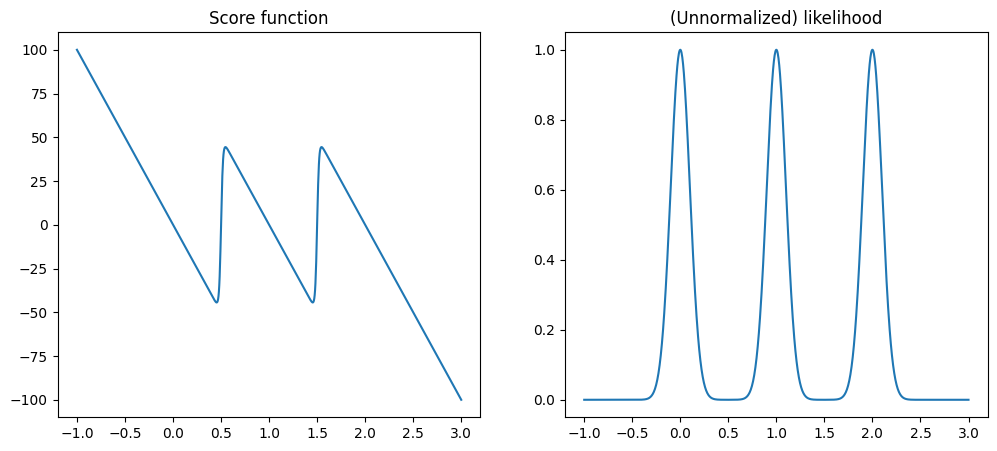

In [717]:
x = np.linspace(-1, 3, 1000)[:, None]
points = np.array([[0], [1], [2]])
sigma = 0.1

score, log_likelihood = x_in_points_score(x, points, sigma)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Score function")
plt.plot(x[:, 0], score[:, 0])

plt.subplot(1, 2, 2)
plt.title("(Unnormalized) likelihood")
plt.plot(x[:, 0], np.exp(log_likelihood))
plt.show()

This looks correct. What about 2D points? For example, if we wanted to constrain $x \in \R^2$ to $\mathcal{C} = \{(0, 1), (1, 0), (1, 1)\}$.


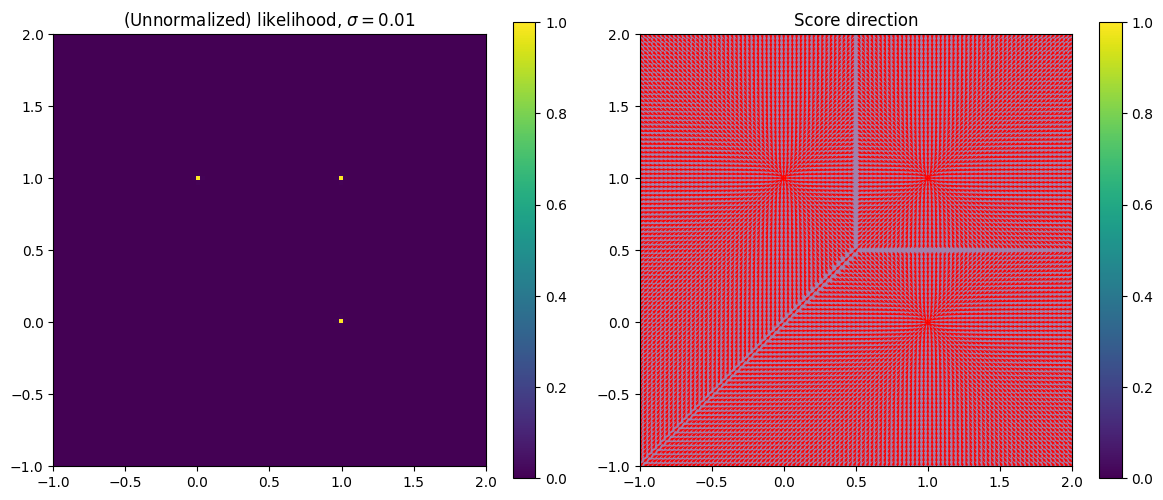

In [718]:
num = 100
xx, yy = np.meshgrid(
    np.linspace(-1, 2, num),
    np.linspace(-1, 2, num),
)
x = np.stack([xx, yy], axis=-1)

points = np.array([[0, 1], [1, 0], [1, 1]])
sigma = 0.01

score, log_likelihood = x_in_points_score(x.reshape(-1, 2), points, sigma)
score = score.reshape(num, num, 2)
log_likelihood = log_likelihood.reshape(num, num)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title(f"(Unnormalized) likelihood, $\\sigma = {sigma:.02f}$")
plt.imshow(
    np.exp(log_likelihood),
    extent=(xx.min(), xx.max(), yy.min(), yy.max()),
    origin="lower",
)
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title("Score direction")
score_normalized = score / (np.linalg.norm(score, axis=-1, keepdims=True) + 1e-40)
plt.imshow(
    np.exp(log_likelihood),
    extent=(xx.min(), xx.max(), yy.min(), yy.max()),
    origin="lower",
    alpha=0.5,
)
dx = xx[0, 1] - xx[0, 0]
dy = yy[1, 0] - yy[0, 0]
plt.quiver(
    xx,
    yy,
    score_normalized[..., 0],
    score_normalized[..., 1],
    color="red",
    angles="xy",
    scale_units="xy",
    scale=1.0 / ((dx**2 + dy**2) ** 0.5),
)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.colorbar()
plt.tight_layout()
plt.show()

It looks like we can successfully constrain the values here. What if we wanted to sample? Let me make a nicer helper function too.


In [556]:
def run_animated_langevin_simulation(
    score_fn,
    likelihood_fn,
    initial_x,
    max_sigma,
    min_sigma,
    n_steps,
    filename,
    heatmap_resolution,
    heatmap_extent_x1_x2_y1_y2: tuple[float, float, float, float],
):
    sigma_values = np.exp(np.linspace(np.log(max_sigma), np.log(min_sigma), n_steps))
    x_hist = langevin_simulation(score_fn, initial_x, sigma_values)

    xx, yy = np.meshgrid(
        np.linspace(
            heatmap_extent_x1_x2_y1_y2[0],
            heatmap_extent_x1_x2_y1_y2[1],
            heatmap_resolution,
        ),
        np.linspace(
            heatmap_extent_x1_x2_y1_y2[2],
            heatmap_extent_x1_x2_y1_y2[3],
            heatmap_resolution,
        ),
    )
    x = np.stack([xx, yy], axis=-1)

    imgs = []

    bytes_io = BytesIO()
    for i in range(1, len(x_hist), n_steps // 100):
        display_sigma = sigma_values[i - 1]
        D = likelihood_fn(x.reshape(-1, 2), display_sigma).reshape(
            heatmap_resolution, heatmap_resolution
        )

        plt.imshow(D, extent=heatmap_extent_x1_x2_y1_y2, origin="lower")
        plt.scatter(x_hist[i][:, 0], x_hist[i][:, 1], alpha=0.5)
        plt.xlim(heatmap_extent_x1_x2_y1_y2[0], heatmap_extent_x1_x2_y1_y2[1])
        plt.ylim(heatmap_extent_x1_x2_y1_y2[2], heatmap_extent_x1_x2_y1_y2[3])
        plt.savefig(bytes_io, format="png")
        plt.clf()

        img = PIL.Image.open(bytes_io, formats=["png"]).convert("RGB")
        imgs.append(img)
        bytes_io.seek(0)
        bytes_io.truncate(0)

    save_video(imgs, filename)

    return x_hist


In [721]:
_ = run_animated_langevin_simulation(
    lambda x, sigma: x_in_points_score(x, np.array([[0, 1], [1, 0], [1, 1]]), sigma)[0]
    + x_in_points_score(x, np.array([[0, 1], [1, 0], [0, 0]]), sigma)[0],
    lambda x, sigma: np.exp(
        x_in_points_score(x, np.array([[0, 1], [1, 0], [1, 1]]), sigma)[1]
        + x_in_points_score(x, np.array([[0, 1], [1, 0], [0, 0]]), sigma)[1]
    ),
    initial_x=np.random.randn(100, 2),
    max_sigma=10,
    min_sigma=0.01,
    n_steps=1000,
    filename="langevin_simulation_points.mp4",
    heatmap_resolution=100,
    heatmap_extent_x1_x2_y1_y2=(-0.5, 1.5, -0.5, 1.5),
)

Video("langevin_simulation_points.mp4")


<Figure size 640x480 with 0 Axes>

In [726]:
_ = run_animated_langevin_simulation(
    lambda x, sigma: x_in_points_score(x, np.array([[0, 1], [1, 0], [1, 1]]), sigma)[0]
    + x_in_points_score(x, np.array([[0, 1], [1, 0], [0, 0]]), sigma)[0],
    lambda x, sigma: np.exp(
        x_in_points_score(x, np.array([[0, 1], [1, 0], [1, 1]]), sigma)[1]
        + x_in_points_score(x, np.array([[0, 1], [1, 0], [0, 0]]), sigma)[1]
    ),
    initial_x=np.random.randn(100, 2),
    max_sigma=10,
    min_sigma=0.001,
    n_steps=100,
    filename="langevin_simulation_points.mp4",
    heatmap_resolution=100,
    heatmap_extent_x1_x2_y1_y2=(-0.5, 1.5, -0.5, 1.5),
)

Video("langevin_simulation_points.mp4")


<Figure size 640x480 with 0 Axes>

For stability reasons, I cap the maximum score magnitude to $100$. It looks like we can successfully sample points though, which is nice. Let's try $3 SAT$ now! For the problem representation, I will index variables starting from $1$. I will represent clauses by tuples of numbers, where a negative number indicates the negation. Then for each clause, I will create a constraint. For a first example, we'll use four variables, with the following clauses:

1. $x_2 \lor x_3 \lor \lnot x_4$
2. $x_1 \lor \lnot x_3 \lor x_4$
3. $x_1 \lor \lnot x_2 \lor x_4$
4. $\lnot x_1 \lor x_2 \lor x_3$


In [811]:
def precompute_three_sat_score(clauses, num_variables, divide_by_n_clauses=True):
    """Generates source code for computing the score."""
    lines = [
        "score = np.zeros_like(x)",
        "log_likelihood = np.zeros(x.shape[0])",
    ]
    n_clauses = np.zeros(num_variables)
    for clause in clauses:
        # compute 'constraints'.
        required = np.sign(clause)
        indices = np.abs(clause) - 1

        # compute valid values.
        values = np.ones((2, 2, 2, 3)) * -1
        values[1, :, :, 0] = 1
        values[:, 1, :, 1] = 1
        values[:, :, 1, 2] = 1
        values = values.reshape(-1, 3)
        ok_mask = np.any(values == required, axis=-1)
        ok_points = values[ok_mask]

        lines.append(f"ok_points = np.array({ok_points.tolist()})")
        lines.append(f"indices = np.array({indices.tolist()})")
        lines.append(
            "clause_score, clause_log_likelihood = x_in_points_score(x[:, indices], ok_points, sigma)"
        )
        lines.append("score[:, indices] += clause_score")
        lines.append("log_likelihood += clause_log_likelihood")
        n_clauses[indices] += 1

    code = "def compute_score(x, sigma):\n"
    for line in lines:
        code += f"\t{line}\n"
    if divide_by_n_clauses:
        code += f"\tn_clauses = np.array({n_clauses.tolist()})\n"
        code += "\treturn score / (n_clauses + 1e-8), log_likelihood\n"
    else:
        code += "\treturn score, log_likelihood\n"

    code += 'func_dropbox["compute_score"] = compute_score'
    func_dropbox = {}

    exec(
        code,
        {
            "np": np,
            "x_in_points_score": x_in_points_score,
            "func_dropbox": func_dropbox,
        },
    )

    return func_dropbox["compute_score"]


def three_sat_score(x, clauses, sigma, divide_by_n_clauses=True):
    # x is (n_particles, n_variables)
    n_particles, n_variables = x.shape
    score = np.zeros_like(x)
    n_clauses = np.zeros_like(x)
    log_likelihood = np.zeros(n_particles)
    for clause in clauses:
        # compute 'constraints'.
        required = np.sign(clause)
        indices = np.abs(clause) - 1

        # compute valid values.
        values = np.ones((2, 2, 2, 3)) * -1
        values[1, :, :, 0] = 1
        values[:, 1, :, 1] = 1
        values[:, :, 1, 2] = 1
        values = values.reshape(-1, 3)
        ok_mask = np.any(values == required, axis=-1)
        ok_points = values[ok_mask]

        clause_score, clause_log_likelihood = x_in_points_score(
            x[:, indices], ok_points, sigma
        )
        score[:, indices] += clause_score
        n_clauses[:, indices] += 1
        log_likelihood += clause_log_likelihood

    return score / ((n_clauses + 1e-8) if divide_by_n_clauses else 1), log_likelihood


def three_sat_score_batched(x, clauses, sigma, divide_by_n_clauses=True):
    """!!! incomplete, implementation is incorrect !!!"""
    # x is (n_particles, n_variables)
    B = x.shape[0]
    score = np.zeros_like(x)
    n_clauses = np.zeros_like(x)
    clauses = np.array(clauses)
    indices_C_I = np.abs(clauses) - 1
    x_subpoints_B_C_3 = x[:, indices_C_I].reshape(
        -1, clauses.shape[0], clauses.shape[1]
    )
    x_subpoints_BC_3 = x_subpoints_B_C_3.reshape(-1, 3)

    # compute valid values.
    required_C_I = np.sign(clauses)
    values = np.ones((2, 2, 2, clauses.shape[0], 3)) * -1
    values[1, :, :, :, 0] = 1
    values[:, 1, :, :, 1] = 1
    values[:, :, 1, :, 2] = 1
    values = values.reshape(2 * 2 * 2, -1, 3)
    ok_8_C = np.any(values == required_C_I, axis=-1)
    ok_values_7_C_3 = values[ok_8_C].reshape(7, clauses.shape[0], 3)
    ok_values_BC_7_3 = np.transpose(ok_values_7_C_3, (1, 0, 2)).repeat(B, axis=0)

    score_BC_3, log_likelihood_BC = x_in_points_score(
        x_subpoints_BC_3, ok_values_BC_7_3, sigma
    )
    score_B_C_3 = score_BC_3.reshape(B, clauses.shape[0], 3)
    log_likelihood_B_C = log_likelihood_BC.reshape(B, clauses.shape[0])
    score = np.zeros_like(x)
    for i in range(clauses.shape[0]):
        score[:, indices_C_I[i]] += score_B_C_3[:, i]
        n_clauses[:, indices_C_I[i]] += 1
    # score[:, indices_C_I] += score_B_C_3
    # n_clauses[:, indices_C_I] += 1
    log_likelihood = log_likelihood_B_C.sum(axis=1)

    return score / ((n_clauses + 1e-8) if divide_by_n_clauses else 1), log_likelihood


def run_and_eval(
    num_variables,
    clauses,
    num_particles=100,
    steps=100,
    max_sigma=10,
    min_sigma=0.01,
    schedule="exponential",
    divide_by_n_clauses=True,
    precompute=False,
):
    if precompute:
        score_fn = precompute_three_sat_score(
            clauses, num_variables, divide_by_n_clauses
        )
    else:
        score_fn = lambda x, sigma: three_sat_score(  # noqa: E731
            x, clauses, sigma, divide_by_n_clauses
        )[0]
    sigma_values = (
        np.exp(np.linspace(np.log(max_sigma), np.log(min_sigma), steps))
        if schedule == "exponential"
        else np.linspace(max_sigma, min_sigma, steps)
    )
    initial_x = np.random.randn(num_particles, num_variables)
    hist = langevin_simulation(
        score_fn,
        initial_x,
        sigma_values,
    )

    ok_fraction = []
    modes = {}

    for i, x in enumerate(hist):
        predicted_values = (x > 0).astype(int) * 2 - 1
        all_ok = np.ones(predicted_values.shape[0], dtype=bool)
        for clause in clauses:
            required = np.sign(clause)
            indices = np.abs(clause) - 1
            any_ok = np.any(predicted_values[:, indices] == required, axis=-1)
            all_ok &= any_ok

        ok_fraction.append(all_ok.mean())

        if i == len(hist) - 1:
            for index in range(len(predicted_values)):
                if all_ok[index]:
                    key = tuple(predicted_values[index].tolist())
                    modes[key] = modes.get(key, 0) + 1

    for key, count in sorted(modes.items()):
        print(f"{key}: {count} particles")

    plt.subplot(1, 2, 1)
    plt.plot(np.linspace(0, steps, len(ok_fraction)), ok_fraction)
    plt.xlabel("Langevin step")
    plt.ylabel("Fraction of particles satisfying all clauses")
    plt.title(f"Langevin Simulation for 3-SAT ({num_variables} variables)")
    plt.ylim(0, 1.1)
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.title("Sigma")
    plt.plot(np.linspace(0, steps, len(sigma_values)), sigma_values)
    plt.xlabel("Langevin step")
    plt.ylabel("Sigma")
    plt.xlim(0, steps)
    plt.ylim(0, max_sigma * 1.1)
    plt.tight_layout()
    plt.grid()
    plt.show()

    return hist, ok_fraction


In [ ]:
def generate_clauses(num_variables, num_clauses):
    clauses = []
    for i in range(num_clauses):
        clause = np.random.choice(
            np.arange(1, num_variables + 1), size=3, replace=False
        )
        clause *= np.random.choice([-1, 1], size=3)
        clauses.append(tuple(clause))
    return clauses

In [809]:
import time

num_variables = 30
num_clauses = 60
clauses = generate_clauses(num_variables, num_clauses)

score = precompute_three_sat_score(clauses, num_variables)

steps = 1000

t0 = time.time()
for _ in range(steps):
    x = np.random.randn(100, num_variables)
    s1, _ = three_sat_score_batched(x, clauses, 0.1)
    # s2, _ = score(x, 0.1)
    # s3, _ = three_sat_score(x, clauses, 0.1)
    # print(np.max(s1 - s2))
t1 = time.time()

print("Time taken for 10,000 calls:", t1 - t0)

t0 = time.time()
for _ in range(steps):
    x = np.random.randn(100, num_variables)
    score(x, 0.1)
t1 = time.time()

print("Time taken for 10,000 calls:", t1 - t0)

t0 = time.time()
for _ in range(steps):
    x = np.random.randn(100, num_variables)
    three_sat_score(x, clauses, 0.1)
t1 = time.time()

print("Time taken for 10,000 calls:", t1 - t0)


Time taken for 10,000 calls: 3.8025262355804443
Time taken for 10,000 calls: 3.081145763397217
Time taken for 10,000 calls: 3.619196891784668


(-1, -1, -1, -1): 13 particles
(-1, -1, 1, 1): 9 particles
(-1, 1, -1, 1): 13 particles
(-1, 1, 1, 1): 7 particles
(1, -1, 1, -1): 8 particles
(1, -1, 1, 1): 6 particles
(1, 1, -1, -1): 14 particles
(1, 1, -1, 1): 7 particles
(1, 1, 1, -1): 11 particles
(1, 1, 1, 1): 7 particles


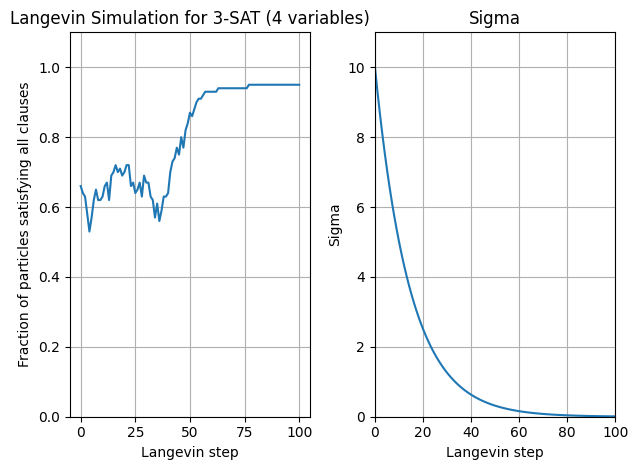

In [814]:
_ = run_and_eval(
    num_variables=4,
    clauses=[
        (2, 3, -4),
        (1, -3, 4),
        (1, -2, 4),
        (-1, 2, 3),
    ],
    precompute=True,
)

Interestingly, it seems like we converge to near-perfect clause satisfaction. However, we must note that this is a very simple problem. What are some more complicated $3 SAT$ problems? We could try generating some.


(-1, -1, -1, -1, -1, -1, 1, 1, -1, 1, 1, 1, 1, -1, 1, -1, 1, 1, 1, 1, 1, -1, 1, 1, 1, -1, 1, 1, -1, -1): 1 particles
(-1, -1, -1, -1, -1, 1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, 1, 1, 1, 1, 1, -1, 1, -1, -1, -1, 1, -1, -1, -1): 1 particles
(-1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, 1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1): 1 particles
(-1, -1, -1, -1, 1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, -1, 1, -1, 1, 1, 1, -1, 1, 1, 1, -1, 1, 1, -1, -1): 1 particles
(-1, -1, -1, -1, 1, 1, 1, 1, -1, 1, -1, -1, -1, -1, 1, -1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, -1, 1, -1): 1 particles
(-1, -1, -1, 1, 1, 1, 1, 1, -1, 1, -1, -1, -1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, 1, 1, -1, 1, 1, -1, -1): 1 particles
(-1, -1, 1, -1, -1, 1, 1, 1, 1, -1, -1, -1, 1, -1, 1, -1, 1, -1, 1, 1, 1, -1, 1, -1, 1, 1, 1, -1, 1, -1): 1 particles
(-1, -1, 1, -1, 1, 1, 1, 1, -1, 1, -1, 1, -1, -1, 1, -1, 1, 1, 1, 1, 1, -1, -1, -1, 1, 1, 1, -1, 1, -1): 1 particles
(-1, -1, 1, 1, -1, -1, 1, -1, 1, -1, 1, 1, -1, -1, 1, -1

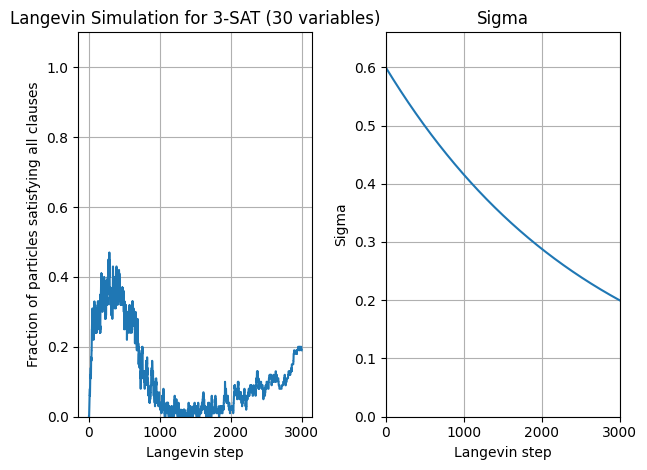

(-1, -1, -1, -1, -1, -1, 1, -1, 1, -1, -1, -1, -1, 1, -1, -1, 1, -1, 1, -1, 1, -1, 1, 1, 1, 1, -1, 1, -1, -1): 1 particles
(-1, -1, -1, -1, -1, -1, 1, 1, -1, -1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1, -1, -1, 1, -1, -1, -1, 1, 1, -1, -1): 1 particles
(-1, -1, -1, -1, -1, -1, 1, 1, -1, 1, 1, 1, -1, -1, 1, -1, 1, -1, -1, -1, 1, -1, 1, 1, 1, 1, 1, 1, -1, -1): 1 particles
(-1, -1, -1, -1, -1, 1, -1, -1, 1, -1, 1, 1, -1, -1, -1, -1, -1, -1, 1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, -1): 1 particles
(-1, -1, -1, -1, -1, 1, 1, 1, 1, -1, -1, 1, -1, 1, -1, -1, -1, -1, 1, -1, 1, 1, 1, -1, -1, 1, 1, 1, 1, -1): 1 particles
(-1, -1, -1, -1, 1, -1, -1, -1, -1, 1, -1, -1, -1, -1, -1, -1, 1, -1, -1, -1, -1, -1, -1, 1, -1, 1, 1, 1, -1, -1): 1 particles
(-1, -1, -1, -1, 1, -1, -1, -1, -1, 1, -1, -1, -1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1): 1 particles
(-1, -1, -1, -1, 1, -1, 1, 1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, -1, 1, -1, 1, -1, -1, -1): 1 particles
(-1, -1, -1, -1, 1, 1, 

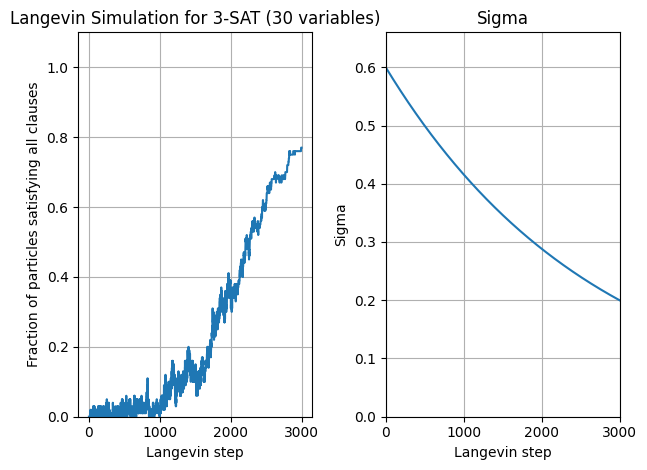

Random guessing: 0.0005 fraction of assignments satisfy all clauses


In [ ]:
run_and_eval(
    num_variables,
    clauses,
    steps=3000,
    num_particles=100,
    max_sigma=0.6,
    min_sigma=0.20,
    divide_by_n_clauses=False,
)
run_and_eval(
    num_variables, clauses, steps=3000, num_particles=100, max_sigma=0.6, min_sigma=0.20
)

# Compare to random guessing.
num_trials = 10000
ok_count = 0
for _ in range(num_trials):
    assignment = np.random.choice([-1, 1], size=num_variables)
    all_ok = True
    for clause in clauses:
        required = np.sign(clause)
        indices = np.abs(clause) - 1
        if not np.any(assignment[indices] == required):
            all_ok = False
            break
    if all_ok:
        ok_count += 1

print(
    f"Random guessing: {ok_count / num_trials:.4f} fraction of assignments satisfy all clauses"
)


One may ask, "why would you not just use a SAT solver?". While it might be unreasonable to use stochastic sampling for problems where deterministic solvers are known, one important distinction is that this approach easily generalizes to continuous constraints and is compatible with diffusion models. Although SMT solvers might be able to find satisfying solutions for continuous constraints, they can't integrate nicely with diffusion model sampling procedures. Also, we see that if we increase the annealing duration, the solvability increases (because there is more mixing time).


(-1, 1, -1, -1, -1, -1, -1, 1, -1, -1): 1 particles
(-1, 1, -1, -1, -1, -1, 1, 1, -1, -1): 1 particles
(-1, 1, -1, -1, -1, -1, 1, 1, 1, 1): 1 particles
(-1, 1, -1, 1, -1, -1, -1, 1, 1, -1): 1 particles
(-1, 1, -1, 1, 1, -1, -1, 1, 1, -1): 1 particles
(-1, 1, -1, 1, 1, -1, 1, 1, 1, -1): 2 particles
(-1, 1, -1, 1, 1, -1, 1, 1, 1, 1): 1 particles
(-1, 1, 1, -1, -1, -1, -1, 1, 1, -1): 1 particles
(-1, 1, 1, -1, -1, -1, 1, 1, -1, -1): 1 particles
(-1, 1, 1, -1, 1, -1, -1, 1, 1, -1): 1 particles
(-1, 1, 1, 1, -1, -1, -1, 1, -1, -1): 2 particles
(-1, 1, 1, 1, -1, -1, -1, 1, 1, -1): 1 particles
(-1, 1, 1, 1, -1, -1, 1, 1, -1, -1): 1 particles
(-1, 1, 1, 1, -1, -1, 1, 1, -1, 1): 1 particles
(-1, 1, 1, 1, -1, -1, 1, 1, 1, 1): 1 particles
(-1, 1, 1, 1, 1, -1, 1, 1, 1, -1): 1 particles
(-1, 1, 1, 1, 1, -1, 1, 1, 1, 1): 2 particles
(1, -1, -1, 1, -1, -1, 1, 1, 1, -1): 1 particles
(1, -1, -1, 1, -1, -1, 1, 1, 1, 1): 2 particles
(1, -1, 1, 1, -1, -1, -1, -1, -1, 1): 2 particles
(1, -1, 1, 1, -1, -1, 

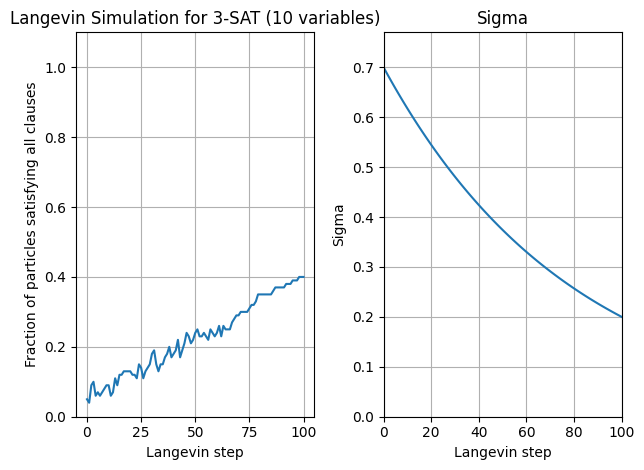

(-1, -1, 1, 1, -1, 1, -1, -1, -1, 1): 1 particles
(-1, -1, 1, 1, -1, 1, -1, -1, 1, 1): 5 particles
(-1, -1, 1, 1, -1, 1, 1, -1, -1, 1): 1 particles
(-1, -1, 1, 1, -1, 1, 1, -1, 1, 1): 2 particles
(-1, 1, -1, -1, -1, -1, -1, 1, 1, -1): 2 particles
(-1, 1, -1, -1, -1, -1, 1, 1, -1, -1): 2 particles
(-1, 1, -1, -1, -1, -1, 1, 1, -1, 1): 3 particles
(-1, 1, -1, -1, -1, -1, 1, 1, 1, -1): 1 particles
(-1, 1, -1, -1, -1, -1, 1, 1, 1, 1): 2 particles
(-1, 1, -1, -1, 1, -1, -1, 1, 1, -1): 3 particles
(-1, 1, -1, -1, 1, -1, 1, 1, 1, 1): 1 particles
(-1, 1, -1, 1, -1, -1, 1, 1, -1, -1): 4 particles
(-1, 1, -1, 1, 1, -1, -1, 1, 1, -1): 1 particles
(-1, 1, -1, 1, 1, -1, 1, 1, 1, 1): 1 particles
(-1, 1, 1, -1, -1, -1, -1, 1, 1, -1): 1 particles
(-1, 1, 1, -1, -1, -1, 1, 1, 1, -1): 1 particles
(-1, 1, 1, -1, 1, -1, -1, 1, 1, -1): 1 particles
(-1, 1, 1, -1, 1, -1, 1, 1, 1, -1): 2 particles
(-1, 1, 1, 1, -1, -1, -1, 1, 1, -1): 1 particles
(-1, 1, 1, 1, -1, -1, 1, 1, -1, -1): 1 particles
(-1, 1, 1, 1, -

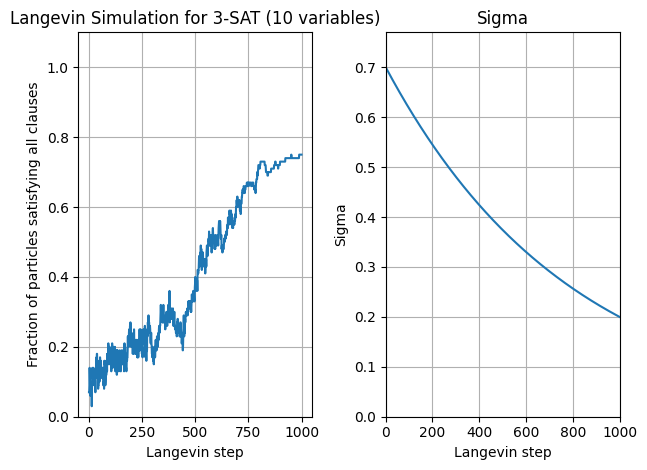

(-1, -1, 1, 1, -1, 1, -1, -1, -1, 1): 3 particles
(-1, -1, 1, 1, -1, 1, -1, -1, 1, 1): 3 particles
(-1, -1, 1, 1, -1, 1, 1, -1, -1, 1): 1 particles
(-1, -1, 1, 1, -1, 1, 1, -1, 1, 1): 3 particles
(-1, 1, -1, -1, -1, -1, -1, 1, 1, -1): 1 particles
(-1, 1, -1, -1, -1, -1, 1, 1, -1, 1): 1 particles
(-1, 1, -1, -1, -1, -1, 1, 1, 1, -1): 1 particles
(-1, 1, -1, -1, -1, -1, 1, 1, 1, 1): 1 particles
(-1, 1, -1, -1, 1, -1, -1, 1, 1, -1): 3 particles
(-1, 1, -1, -1, 1, -1, 1, 1, 1, -1): 2 particles
(-1, 1, -1, -1, 1, -1, 1, 1, 1, 1): 1 particles
(-1, 1, -1, 1, -1, -1, 1, 1, -1, -1): 1 particles
(-1, 1, -1, 1, -1, -1, 1, 1, -1, 1): 1 particles
(-1, 1, -1, 1, -1, -1, 1, 1, 1, -1): 1 particles
(-1, 1, -1, 1, 1, -1, -1, 1, 1, -1): 4 particles
(-1, 1, -1, 1, 1, -1, 1, 1, 1, -1): 1 particles
(-1, 1, -1, 1, 1, -1, 1, 1, 1, 1): 2 particles
(-1, 1, 1, -1, -1, -1, -1, 1, -1, -1): 1 particles
(-1, 1, 1, -1, -1, -1, -1, 1, 1, -1): 3 particles
(-1, 1, 1, -1, -1, -1, 1, 1, -1, -1): 1 particles
(-1, 1, 1, 1, 

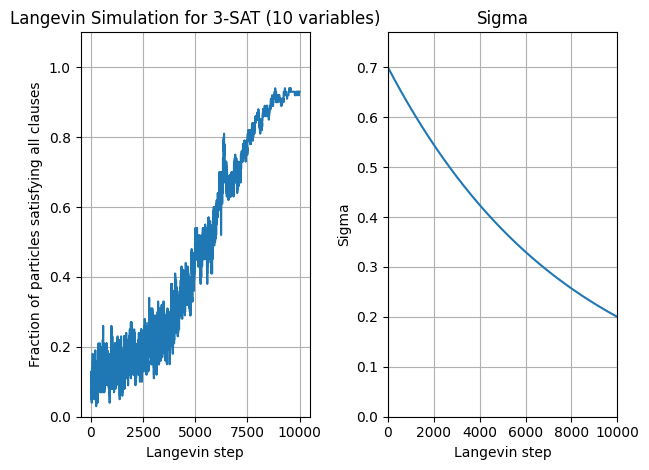

Random guessing: 0.0610 fraction of assignments satisfy all clauses


In [ ]:
generator = np.random.default_rng(seed=42)
num_variables = 10
num_clauses = 20
clauses = []
for i in range(num_clauses):
    clause = generator.choice(np.arange(1, num_variables + 1), size=3, replace=False)
    clause *= generator.choice([-1, 1], size=3)
    clauses.append(tuple(clause))

for steps in [100, 1000, 10000]:
    # run_and_eval(num_variables, clauses, steps=steps, num_particles=100, min_sigma=0.01, max_sigma=1.0, schedule='linear')
    run_and_eval(
        num_variables,
        clauses,
        steps=steps,
        num_particles=100,
        min_sigma=0.2,
        max_sigma=0.7,
        schedule="exponential",
    )

# Compare to random guessing.
num_trials = 10000
ok_count = 0
for _ in range(num_trials):
    assignment = generator.choice([-1, 1], size=num_variables)
    all_ok = True
    for clause in clauses:
        required = np.sign(clause)
        indices = np.abs(clause) - 1
        if not np.any(assignment[indices] == required):
            all_ok = False
            break
    if all_ok:
        ok_count += 1

print(
    f"Random guessing: {ok_count / num_trials:.4f} fraction of assignments satisfy all clauses"
)


It's weird to me that there are lots of satisfying clauses at around $\sigma = 0.55$, but that they drop off. Is something wrong with my implementation at low $\sigma$ values? It could be that there is too much noise...

Well, actually $dx = -\eta \nabla_x U(x) \, dt + \sqrt{2 \eta} \, dW_t$. Here when I sample $dW_t$ I should be taking samples with variance $dt$. This means if I take discrete timesteps $\Delta t$, I should have $\Delta x = -\eta \nabla_x U(x) \Delta t + \sqrt{2 \eta \Delta t} z$ where $z \sim \mathcal{N}(0, I)$. In effect though, decreasing $\Delta t$ is the exact same as decreasing $\eta$ and keeping $\Delta t$ constant. Looking carefully at the videos, it kind of looks like the annealing is too fast at low noise levels.


(-1, -1, -1, 1): 15 particles
(-1, -1, 1, -1): 9 particles
(-1, -1, 1, 1): 4 particles
(1, -1, 1, -1): 11 particles
(1, -1, 1, 1): 7 particles
(1, 1, -1, 1): 25 particles
(1, 1, 1, -1): 5 particles


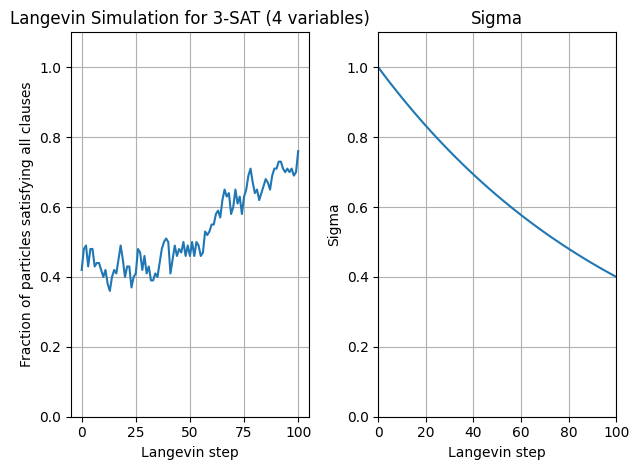

(-1, -1, -1, 1): 11 particles
(-1, -1, 1, -1): 17 particles
(-1, -1, 1, 1): 14 particles
(1, -1, 1, -1): 10 particles
(1, -1, 1, 1): 11 particles
(1, 1, -1, 1): 10 particles
(1, 1, 1, -1): 6 particles


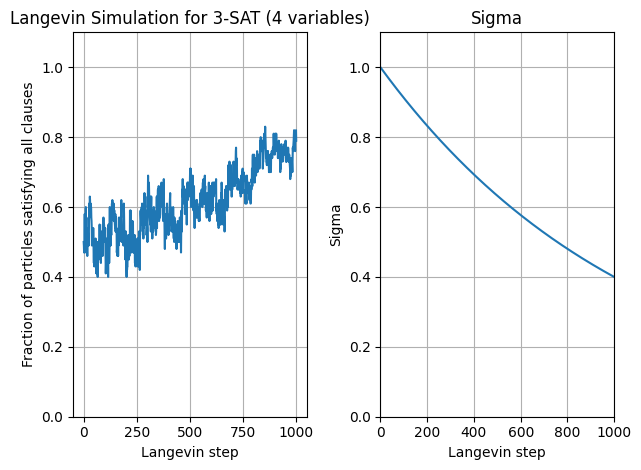

(-1, -1, -1, 1): 14 particles
(-1, -1, 1, -1): 14 particles
(-1, -1, 1, 1): 13 particles
(1, -1, 1, -1): 13 particles
(1, -1, 1, 1): 9 particles
(1, 1, -1, 1): 10 particles
(1, 1, 1, -1): 11 particles


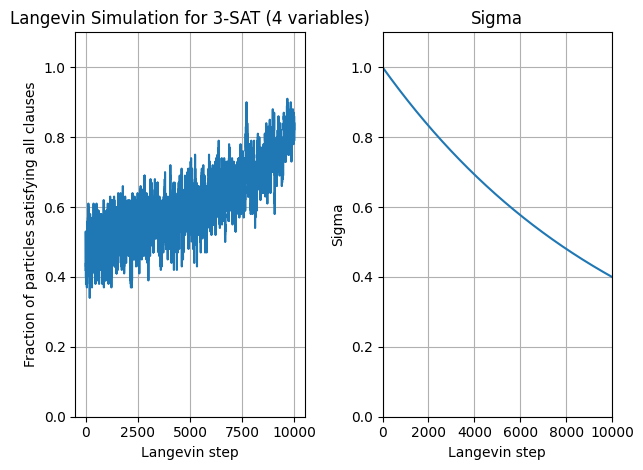

Random guessing: 0.4385 fraction of assignments satisfy all clauses


In [ ]:
generator = np.random.default_rng(seed=42)
num_variables = 4
num_clauses = 8
clauses = []
for i in range(num_clauses):
    clause = generator.choice(np.arange(1, num_variables + 1), size=3, replace=False)
    clause *= generator.choice([-1, 1], size=3)
    clauses.append(tuple(clause))

for steps in [100, 1000, 10000]:
    # run_and_eval(num_variables, clauses, steps=steps, num_particles=100, min_sigma=0.01, max_sigma=1.0, schedule='linear')
    run_and_eval(
        num_variables,
        clauses,
        steps=steps,
        num_particles=100,
        min_sigma=0.4,
        max_sigma=1.0,
        schedule="exponential",
    )

# Compare to random guessing.
num_trials = 10000
ok_count = 0
for _ in range(num_trials):
    assignment = generator.choice([-1, 1], size=num_variables)
    all_ok = True
    for clause in clauses:
        required = np.sign(clause)
        indices = np.abs(clause) - 1
        if not np.any(assignment[indices] == required):
            all_ok = False
            break
    if all_ok:
        ok_count += 1

print(
    f"Random guessing: {ok_count / num_trials:.4f} fraction of assignments satisfy all clauses"
)


(1, -1, 1): 26 particles
(1, 1, -1): 23 particles


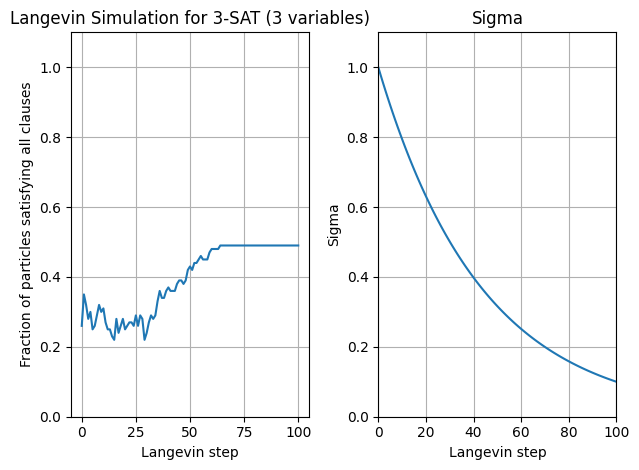

(1, -1, 1): 31 particles
(1, 1, -1): 37 particles


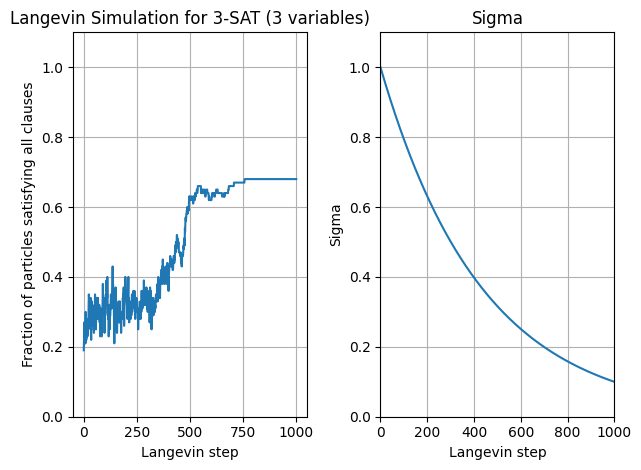

(1, -1, 1): 41 particles
(1, 1, -1): 38 particles


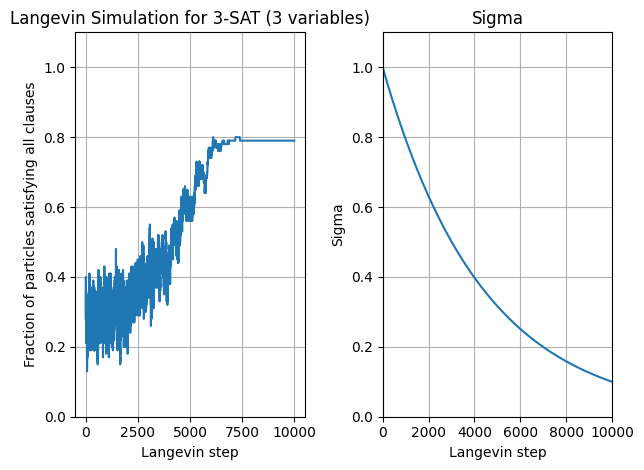

Random guessing: 0.2479 fraction of assignments satisfy all clauses


In [ ]:
generator = np.random.default_rng(seed=42)
num_variables = 3
num_clauses = 10
clauses = []
for i in range(num_clauses):
    clause = generator.choice(np.arange(1, num_variables + 1), size=3, replace=False)
    clause *= generator.choice([-1, 1], size=3)
    clauses.append(tuple(clause))

for steps in [100, 1000, 10000]:
    # run_and_eval(num_variables, clauses, steps=steps, num_particles=100, min_sigma=0.01, max_sigma=1.0, schedule='linear')
    run_and_eval(
        num_variables,
        clauses,
        steps=steps,
        num_particles=100,
        min_sigma=0.1,
        max_sigma=1.0,
        schedule="exponential",
    )

# Compare to random guessing.
num_trials = 10000
ok_count = 0
for _ in range(num_trials):
    assignment = generator.choice([-1, 1], size=num_variables)
    all_ok = True
    for clause in clauses:
        required = np.sign(clause)
        indices = np.abs(clause) - 1
        if not np.any(assignment[indices] == required):
            all_ok = False
            break
    if all_ok:
        ok_count += 1

print(
    f"Random guessing: {ok_count / num_trials:.4f} fraction of assignments satisfy all clauses"
)


(-1, -1, -1, -1, 1, -1, 1, -1): 1 particles
(-1, -1, 1, -1, 1, -1, 1, 1): 3 particles
(-1, -1, 1, -1, 1, 1, -1, 1): 1 particles
(-1, -1, 1, 1, 1, 1, -1, 1): 2 particles
(-1, 1, 1, -1, 1, 1, -1, 1): 2 particles
(-1, 1, 1, 1, 1, 1, -1, 1): 3 particles
(1, -1, -1, -1, -1, -1, -1, 1): 1 particles
(1, -1, -1, -1, 1, 1, -1, -1): 2 particles
(1, -1, -1, -1, 1, 1, -1, 1): 1 particles
(1, -1, -1, 1, -1, -1, -1, 1): 3 particles
(1, -1, -1, 1, 1, 1, -1, -1): 2 particles
(1, -1, -1, 1, 1, 1, -1, 1): 1 particles
(1, -1, 1, -1, -1, -1, -1, 1): 1 particles
(1, -1, 1, -1, -1, -1, 1, 1): 1 particles
(1, -1, 1, -1, -1, 1, -1, -1): 1 particles
(1, -1, 1, -1, -1, 1, 1, -1): 1 particles
(1, -1, 1, -1, -1, 1, 1, 1): 1 particles
(1, -1, 1, -1, 1, -1, 1, 1): 2 particles
(1, -1, 1, -1, 1, 1, -1, 1): 1 particles
(1, -1, 1, 1, -1, -1, -1, 1): 1 particles
(1, -1, 1, 1, -1, -1, 1, 1): 2 particles
(1, -1, 1, 1, -1, 1, -1, -1): 2 particles
(1, -1, 1, 1, -1, 1, -1, 1): 3 particles
(1, -1, 1, 1, -1, 1, 1, -1): 1 parti

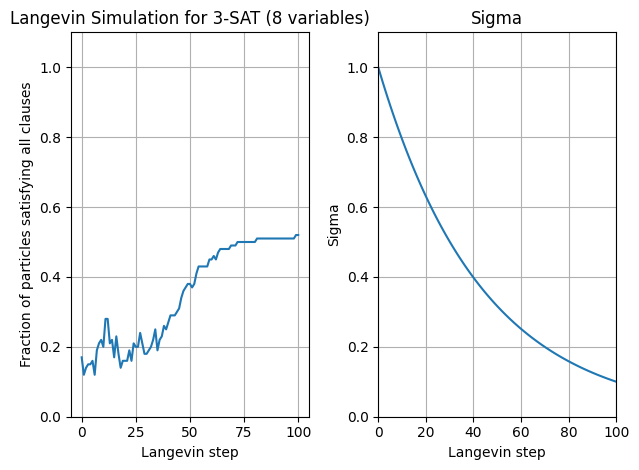

(-1, -1, -1, -1, 1, -1, 1, -1): 3 particles
(-1, -1, 1, -1, 1, -1, 1, -1): 4 particles
(-1, -1, 1, -1, 1, 1, -1, -1): 3 particles
(-1, -1, 1, -1, 1, 1, -1, 1): 3 particles
(-1, -1, 1, 1, 1, 1, -1, 1): 2 particles
(-1, 1, 1, -1, 1, 1, -1, -1): 1 particles
(-1, 1, 1, -1, 1, 1, -1, 1): 1 particles
(-1, 1, 1, 1, 1, 1, -1, 1): 3 particles
(1, -1, -1, -1, -1, -1, -1, 1): 1 particles
(1, -1, -1, -1, 1, 1, -1, 1): 1 particles
(1, -1, -1, 1, -1, -1, -1, 1): 5 particles
(1, -1, -1, 1, 1, 1, -1, -1): 1 particles
(1, -1, -1, 1, 1, 1, -1, 1): 2 particles
(1, -1, 1, -1, -1, -1, -1, 1): 1 particles
(1, -1, 1, -1, -1, -1, 1, 1): 7 particles
(1, -1, 1, -1, -1, 1, -1, -1): 3 particles
(1, -1, 1, -1, -1, 1, -1, 1): 2 particles
(1, -1, 1, -1, -1, 1, 1, -1): 1 particles
(1, -1, 1, -1, -1, 1, 1, 1): 3 particles
(1, -1, 1, -1, 1, -1, 1, 1): 2 particles
(1, -1, 1, -1, 1, 1, -1, -1): 1 particles
(1, -1, 1, -1, 1, 1, -1, 1): 2 particles
(1, -1, 1, 1, -1, -1, -1, 1): 6 particles
(1, -1, 1, 1, -1, -1, 1, 1): 5 pa

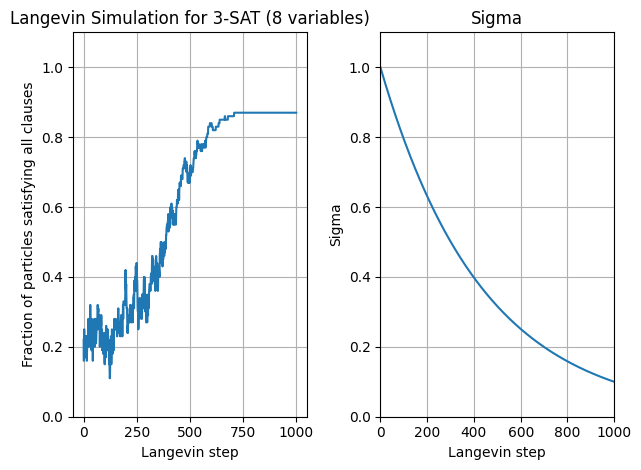

(-1, -1, 1, -1, 1, -1, 1, -1): 2 particles
(-1, -1, 1, -1, 1, -1, 1, 1): 1 particles
(-1, -1, 1, -1, 1, 1, -1, -1): 3 particles
(-1, -1, 1, -1, 1, 1, -1, 1): 2 particles
(-1, -1, 1, 1, 1, 1, -1, 1): 5 particles
(-1, 1, 1, -1, 1, 1, -1, -1): 3 particles
(-1, 1, 1, -1, 1, 1, -1, 1): 2 particles
(1, -1, -1, -1, -1, -1, -1, 1): 1 particles
(1, -1, -1, -1, 1, 1, -1, -1): 1 particles
(1, -1, -1, 1, -1, -1, -1, 1): 2 particles
(1, -1, 1, -1, -1, -1, -1, 1): 5 particles
(1, -1, 1, -1, -1, -1, 1, 1): 5 particles
(1, -1, 1, -1, -1, 1, -1, -1): 2 particles
(1, -1, 1, -1, -1, 1, -1, 1): 2 particles
(1, -1, 1, -1, -1, 1, 1, -1): 2 particles
(1, -1, 1, -1, -1, 1, 1, 1): 6 particles
(1, -1, 1, -1, 1, -1, 1, 1): 9 particles
(1, -1, 1, -1, 1, 1, -1, -1): 3 particles
(1, -1, 1, -1, 1, 1, -1, 1): 2 particles
(1, -1, 1, 1, -1, -1, -1, 1): 6 particles
(1, -1, 1, 1, -1, -1, 1, 1): 4 particles
(1, -1, 1, 1, -1, 1, -1, -1): 4 particles
(1, -1, 1, 1, -1, 1, -1, 1): 4 particles
(1, -1, 1, 1, -1, 1, 1, -1): 4 pa

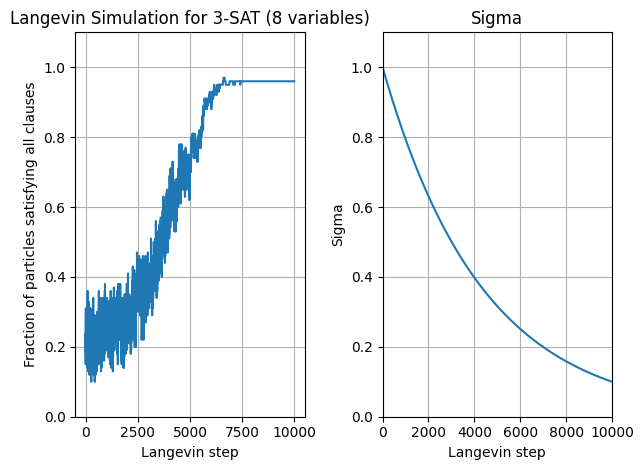

Random guessing: 0.1552 fraction of assignments satisfy all clauses


In [ ]:
generator = np.random.default_rng(seed=42)
num_variables = 8
num_clauses = 16
clauses = []
for i in range(num_clauses):
    clause = generator.choice(np.arange(1, num_variables + 1), size=3, replace=False)
    clause *= generator.choice([-1, 1], size=3)
    clauses.append(tuple(clause))

for steps in [100, 1000, 10000]:
    # run_and_eval(num_variables, clauses, steps=steps, num_particles=100, min_sigma=0.01, max_sigma=1.0, schedule='linear')
    run_and_eval(
        num_variables,
        clauses,
        steps=steps,
        num_particles=100,
        min_sigma=0.1,
        max_sigma=1.0,
        schedule="exponential",
    )

# Compare to random guessing.
num_trials = 10000
ok_count = 0
for _ in range(num_trials):
    assignment = generator.choice([-1, 1], size=num_variables)
    all_ok = True
    for clause in clauses:
        required = np.sign(clause)
        indices = np.abs(clause) - 1
        if not np.any(assignment[indices] == required):
            all_ok = False
            break
    if all_ok:
        ok_count += 1

print(
    f"Random guessing: {ok_count / num_trials:.4f} fraction of assignments satisfy all clauses"
)


It looks like the "peak" noise level is dependent on the number of variables; i.e., the dimensionality of the space. I wonder if the sigma values I'm finding the 'phase transition' of sorts to occur at is where local minima begin to appear. If so, then I might need to allow for more mixing at that point. Although this does seem not to really depend on how many steps I allow.

I thought about it a bit and I think one issue might be the scaling of the energy landscape. There are potentially several overlapping energy landscapes for the same feasible points; this could make it harder to escape local minima. After fixing this looks like I get nice monotonically increasing satisfaction curves! Maybe I'll add a flag to allow comparing the two directly.


(-1, -1, -1, 1, 1, -1, 1, -1, -1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, 1, 1, 1, 1, -1, 1, 1, 1, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1, -1, -1, 1, -1, -1, -1, 1, -1, 1, 1, -1, 1, -1, -1, 1, 1, -1, -1, -1, 1, -1, -1, -1, -1, -1, -1, 1, 1, -1, 1, 1, -1, 1, -1, 1, 1, -1, -1, 1, -1, -1, -1, -1, -1, -1, -1, 1, 1, -1, 1, 1): 1 particles
(-1, -1, 1, -1, -1, -1, 1, 1, -1, 1, 1, 1, -1, 1, 1, -1, 1, 1, -1, -1, 1, -1, -1, -1, 1, 1, 1, 1, -1, -1, -1, 1, 1, 1, 1, -1, 1, 1, 1, 1, -1, -1, 1, -1, -1, -1, -1, -1, 1, -1, -1, 1, -1, -1, -1, 1, -1, -1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, -1, -1, -1, 1, -1, 1, -1, 1, 1, 1, 1, 1, 1, -1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1): 1 particles
(-1, -1, 1, -1, 1, -1, -1, -1, 1, 1, 1, 1, -1, 1, 1, -1, -1, 1, 1, -1, -1, -1, 1, -1, 1, 1, 1, 1, 1, 1, -1, 1, -1, 1, -1, -1, 1, 1, 1, 1, -1, -1, -1, -1, 1, 1, 1, -1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, -1, -1, -1, -1, -1, -1, 1, -1, -1, -1, -1, -1, 1, -1, 1, -1, 1, -

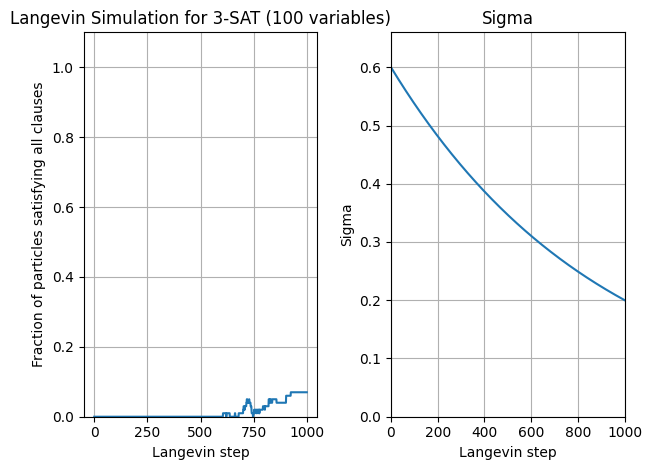

Langevin simulation: 0.0700 final fraction of particles satisfying all clauses (13.56 seconds)
Random guessing: 0.0000 fraction of assignments satisfy all clauses (4.00 seconds)


In [817]:
import time

num_variables = 100
num_clauses = 200
clauses = []
for i in range(num_clauses):
    clause = np.random.choice(np.arange(1, num_variables + 1), size=3, replace=False)
    clause *= np.random.choice([-1, 1], size=3)
    clauses.append(tuple(clause))


steps = 1000
num_particles = 100

# run_and_eval(num_variables, clauses, steps=500, num_particles=100, max_sigma=0.6, min_sigma=0.20, divide_by_n_clauses=False)
t0 = time.time()
hist, ok_fraction = run_and_eval(
    num_variables,
    clauses,
    steps=steps,
    num_particles=num_particles,
    max_sigma=0.6,
    min_sigma=0.2,
)
t1 = time.time()

print(
    f"Langevin simulation: {ok_fraction[-1]:.4f} final fraction of particles satisfying all clauses ({t1 - t0:.2f} seconds)"
)

# Compare to random guessing.
t0 = time.time()
num_trials = steps * num_particles
ok_count = 0
for _ in range(num_trials):
    assignment = np.random.choice([-1, 1], size=num_variables)
    all_ok = True
    for clause in clauses:
        required = np.sign(clause)
        indices = np.abs(clause) - 1
        if not np.any(assignment[indices] == required):
            all_ok = False
            break
    if all_ok:
        ok_count += 1
t1 = time.time()

print(
    f"Random guessing: {ok_count / num_trials:.4f} fraction of assignments satisfy all clauses ({t1 - t0:.2f} seconds)"
)


In [ ]:
# compare to simulated annealing, another randomized algorithm
def simulated_annealing_three_sat():
    pass